# Estimación del costo unitario de transformación en órdenes farmacéuticas

Se estudian registros de producción de cápsulas duras para estimar el costo unitario de transformación (`costo_transformacion`). Después de excluir cinco órdenes con volumen no positivo y cuatro sin insumos, quedan **529 órdenes** de **145 productos**. El EDA y el ajuste utilizan una muestra aleatoria de entrenamiento; otra muestra aleatoria de órdenes se reserva para la evaluación final. Un mismo producto puede aparecer en ambos conjuntos. La duración se expresa en horas, los costos en COP y los consumos de insumos en kg. No se dispone de una unidad documentada para `volumen_lote`.

El estudio asume un proceso estacionario y excluye la variable `periodo`. Describe la distribución del costo y su relación con características de producto, equipo e insumos; después compara especificaciones Ridge y evalúa su capacidad predictiva. Las variables observadas durante la ejecución se tratan como información posterior y no como predictores operativos.

## 1. Pregunta y objetivo

> **¿En qué medida las características de producto, volumen, equipo, insumos y modalidad de proceso permiten estimar el costo unitario de transformación de una orden?**

La unidad de análisis es la orden de producción y la respuesta es `costo_transformacion`. El interés está en estimar el costo con información disponible al especificar la orden. Las asociaciones exploratorias describen patrones en los datos; no establecen relaciones causales.

## 2. Datos y métodos

El análisis comprende **529 órdenes** de producción de cápsulas duras y **145 productos**. Se excluyeron cinco órdenes con volumen de lote no positivo y cuatro sin insumos registrados. La respuesta es el costo unitario de transformación, en COP por unidad producida. La duración está expresada en horas y el consumo de insumos en kilogramos; la unidad de `volumen_lote` no está especificada. La fuente y la licencia no constan en los archivos disponibles.

Se adopta el supuesto de estacionariedad para estudiar relaciones entre características de la orden y costo. En consecuencia, `periodo` se excluye del análisis y de los predictores. La ausencia de `insumo_2` cuando `num_insumos = 1` representa una configuración de un solo insumo, no un dato faltante que deba imputarse como si existiera un segundo material.

La muestra se dividió aleatoriamente por orden: **423 registros** para exploración y desarrollo y **106** para evaluación final. Los productos pueden estar presentes en ambos conjuntos; 47 de los 60 códigos de producto de prueba aparecen también en entrenamiento; los restantes surgen solo en la muestra de prueba. La validación cruzada aleatoria estima el desempeño para órdenes nuevas de un catálogo conocido. La validación agrupada por `codigo_producto` se conserva como análisis complementario de transferencia a productos no vistos. Como los datos se habían examinado en etapas anteriores, la prueba reservada no constituye una evaluación completamente ciega.

La exploración describe calidad, distribución, asociaciones y diferencias entre grupos. Se comparan Ridge A —variables disponibles al definir la orden— y Ridge B, que añade `tipo_equipo` y `num_insumos`. La imputación, estandarización, codificación y selección de `alpha` se ajustan dentro de cada pliegue. Las métricas incluyen RMSE, MAE, MAPE y $R^2$; Ridge se contrasta con la predicción de la media y se inspeccionan sus residuos.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
SEMILLA = 42

candidate_paths = [
    Path("/content/data_costos.csv"),
    Path("data_costos.csv"),
    Path("/mnt/data/data_costos.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data_costos.csv. Coloca el archivo en la carpeta del notebook.")

TARGET = "costo_transformacion"
df_original = pd.read_csv(DATA_PATH, sep=";")
n_ordenes_original = len(df_original)
for columna in ["volumen_lote", "num_insumos", TARGET]:
    df_original[columna] = pd.to_numeric(df_original[columna], errors="coerce")
mask_volumen_valido = df_original["volumen_lote"] > 0
n_ordenes_excluidas_volumen = int((~mask_volumen_valido).sum())
df_volumen_valido = df_original.loc[mask_volumen_valido].copy()
mask_con_insumos = df_volumen_valido["num_insumos"] > 0
n_ordenes_excluidas_sin_insumos = int((~mask_con_insumos).sum())
df_elegible = df_volumen_valido.loc[mask_con_insumos].dropna(subset=[TARGET]).copy().reset_index(drop=True)
# El análisis adopta un enfoque estacionario y excluye la variable temporal.
df_elegible = df_elegible.drop(columns=["periodo"], errors="ignore")

# Separación aleatoria por orden, con productos compartidos permitidos entre conjuntos.
df, df_test = train_test_split(
    df_elegible, test_size=0.20, random_state=SEMILLA, shuffle=True
)
df = df.copy().reset_index(drop=True)
df_test = df_test.copy().reset_index(drop=True)
productos_train = set(df["codigo_producto"].astype(str))
productos_test = set(df_test["codigo_producto"].astype(str))
productos_compartidos = productos_train & productos_test

print(f"Archivo analizado: {DATA_PATH.name}")
print(f"Órdenes originales: {n_ordenes_original:,}; excluidas por volumen no positivo: {n_ordenes_excluidas_volumen}; sin insumos: {n_ordenes_excluidas_sin_insumos}")
print(f"Población elegible: {len(df_elegible):,} órdenes y {df_elegible['codigo_producto'].nunique()} productos")
print(f"Entrenamiento/EDA: {len(df):,} órdenes, {df['codigo_producto'].nunique()} productos")
print(f"Prueba aleatoria: {len(df_test):,} órdenes, {df_test['codigo_producto'].nunique()} productos")
print(f"Productos presentes en ambos conjuntos: {len(productos_compartidos)}")

Archivo analizado: data_costos.csv
Órdenes originales: 538; excluidas por volumen no positivo: 5; sin insumos: 4
Población elegible: 529 órdenes y 145 productos
Entrenamiento/EDA: 423 órdenes, 132 productos
Prueba aleatoria: 106 órdenes, 60 productos
Productos presentes en ambos conjuntos: 47


## 3. Resultados

### Diccionario operativo de variables

La tabla resume el papel analítico de las variables y las unidades confirmadas. Los códigos de producto, equipo, insumo y categoría requieren un diccionario institucional para una interpretación semántica completa.

In [2]:
diccionario = pd.DataFrame([
    ("codigo_producto", "Categórica nominal", "Código del producto/SKU"),
    ("id_orden", "Identificador", "Identificador único de la orden"),
    ("volumen_lote", "Numérica", "Volumen de lote; unidad no especificada"),
    ("costo_transformacion", "Numérica continua; objetivo", "Costo unitario de transformación (COP/unidad producida)"),
    ("costo_insumo", "Numérica continua", "Costo de insumos (COP); observado en la ejecución"),
    ("equipo_id", "Categórica nominal", "Identificador del equipo individual"),
    ("tipo_equipo", "Categórica nominal", "Tipo/familia de máquina"),
    ("categoria_producto", "Categórica nominal codificada", "Categoría del producto; etiquetas semánticas no disponibles"),
    ("num_insumos", "Discreta", "Número de insumos registrados"),
    ("insumo_1, insumo_2", "Categórica nominal", "Códigos de insumo; nombres no disponibles"),
    ("cantidad_insumo_1, cantidad_insumo_2", "Numérica continua", "Consumo de insumos (kg); observado en la ejecución"),
    ("modalidad_proceso", "Categórica nominal", "Modalidad/código del proceso; descripción no disponible"),
    ("duracion_proceso", "Numérica continua", "Duración del proceso (horas); observada en la ejecución"),
], columns=["variable", "tipo", "significado_y_unidad"])
display(diccionario)

,variable,tipo,significado_y_unidad
0,codigo_producto,Categórica nominal,Código del producto/SKU
1,id_orden,Identificador,Identificador único de la orden
2,volumen_lote,Numérica,Volumen de lote; unidad no especificada
3,costo_transformacion,Numérica continua; objetivo,Costo unitario de transformación (COP/unidad p...
4,costo_insumo,Numérica continua,Costo de insumos (COP); observado en la ejecución
5,equipo_id,Categórica nominal,Identificador del equipo individual
6,tipo_equipo,Categórica nominal,Tipo/familia de máquina
7,categoria_producto,Categórica nominal codificada,Categoría del producto; etiquetas semánticas n...
8,num_insumos,Discreta,Número de insumos registrados
9,"insumo_1, insumo_2",Categórica nominal,Códigos de insumo; nombres no disponibles


El diccionario distingue el objetivo, los identificadores y las variables observadas durante la ejecución. La procedencia, la autorización de uso y el significado de los códigos deben confirmarse con la fuente de los datos antes de su difusión externa.

### 3.1 Completitud y estructura

In [3]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes_n": df.isna().sum(),
    "faltantes_pct": (100 * df.isna().mean()).round(1),
    "valores_distintos": df.nunique(dropna=True),
})
display(resumen_calidad)
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Identificadores de orden únicos: {df['id_orden'].nunique()} de {len(df)}")
print(f"Códigos de producto: {df['codigo_producto'].nunique()}")

,tipo,faltantes_n,faltantes_pct,valores_distintos
codigo_producto,object,0,0.0,132
id_orden,int64,0,0.0,423
volumen_lote,float64,0,0.0,306
costo_transformacion,float64,0,0.0,422
costo_insumo,float64,0,0.0,419
equipo_id,object,0,0.0,12
tipo_equipo,object,0,0.0,4
categoria_producto,int64,0,0.0,7
num_insumos,int64,0,0.0,2
insumo_1,object,0,0.0,7


Filas duplicadas exactas: 0
Identificadores de orden únicos: 423 de 423
Códigos de producto: 132


Tras los filtros quedan **529 órdenes elegibles**. La partición aleatoria deja **423 órdenes** para EDA y desarrollo, y reserva **106** para la evaluación final. En entrenamiento hay **132 productos**; 47 de los 60 productos de prueba aparecen también en entrenamiento. La prueba incluye productos conocidos y otros que solo aparecen en esa muestra; no está diseñada para aislar el desempeño en productos inéditos.

In [4]:
revision_insumos = (df.groupby("num_insumos", dropna=False)
    .agg(ordenes=(TARGET, "size"),
         faltantes_insumo_1=("insumo_1", lambda s: s.isna().sum()),
         faltantes_insumo_2=("insumo_2", lambda s: s.isna().sum()))
    .reset_index())
display(revision_insumos)

,num_insumos,ordenes,faltantes_insumo_1,faltantes_insumo_2
0,1,251,0,251
1,2,172,0,0


En entrenamiento, las **251 órdenes** con un insumo no registran `insumo_2`; las **172 órdenes** con dos insumos sí tienen ambos campos informados. La correspondencia entre `num_insumos` e `insumo_2` confirma que esta ausencia es estructural y que el campo aporta información sobre la configuración de la orden.

#### Perfil univariado de predictores y calidad de datos

Las siguientes tablas y gráficos describen las órdenes de entrenamiento seleccionadas aleatoriamente. Los códigos se tratan como categorías nominales, no como magnitudes ordenadas.

In [5]:
variables_numericas_eda = ["volumen_lote", "costo_insumo", "duracion_proceso", "cantidad_insumo_1", "cantidad_insumo_2"]
resumen_predictores = df[variables_numericas_eda].describe(percentiles=[.25, .5, .75, .95]).T
resumen_predictores["asimetria"] = df[variables_numericas_eda].skew()
resumen_predictores["curtosis_exceso"] = df[variables_numericas_eda].kurtosis()
display(resumen_predictores.round(2))

categoricas_eda = ["equipo_id", "tipo_equipo", "categoria_producto", "num_insumos", "insumo_1", "insumo_2", "modalidad_proceso"]
filas_frecuencia = []
for variable in categoricas_eda:
    conteos = df[variable].value_counts(dropna=False)
    for nivel, n_nivel in conteos.items():
        filas_frecuencia.append({
            "variable": variable, "categoria": "[FALTANTE]" if pd.isna(nivel) else str(nivel),
            "n": int(n_nivel), "porcentaje": 100 * n_nivel / len(df),
            "categoria_rara_<5%": 100 * n_nivel / len(df) < 5,
        })
tabla_frecuencias = pd.DataFrame(filas_frecuencia)
display(tabla_frecuencias.round(2))

,count,mean,std,min,25%,50%,75%,95%,max,asimetria,curtosis_exceso
volumen_lote,423.0,2713.38,2135.19,100.00,1273.00,2034.0,3331.00,7148.7,12075.00,1.77,3.41
costo_insumo,423.0,5.23,4.14,0.08,2.85,4.5,6.37,12.2,46.22,4.10,30.67
duracion_proceso,423.0,125.64,88.54,3.00,62.00,105.0,169.50,302.6,500.00,1.17,1.39
cantidad_insumo_1,423.0,2.33,1.94,0.00,1.00,2.0,3.00,6.0,14.00,1.86,5.40
cantidad_insumo_2,423.0,0.63,1.20,0.00,0.00,0.0,1.00,3.0,7.00,2.77,9.23


,variable,categoria,n,porcentaje,categoria_rara_<5%
0,equipo_id,M16,52,12.29,False
1,equipo_id,M14,51,12.06,False
2,equipo_id,M17,50,11.82,False
3,equipo_id,M02,49,11.58,False
4,equipo_id,M09,48,11.35,False
5,equipo_id,M15,47,11.11,False
6,equipo_id,M13,40,9.46,False
7,equipo_id,M05,32,7.57,False
8,equipo_id,M08,30,7.09,False
9,equipo_id,M12,17,4.02,True


La tabla de estadísticos muestra escalas y asimetrías distintas: costo de insumos, volumen y consumos presentan colas hacia valores altos; la cantidad del segundo insumo tiene muchos ceros porque numerosas órdenes usan un solo insumo. La tabla de frecuencias evidencia concentración en `A1`, la categoría de producto 5 y algunos códigos de insumo. Los niveles con menos del 5 % se señalan como raros y se conservan; `equipo_id` y `codigo_producto` se interpretan como identificadores nominales.

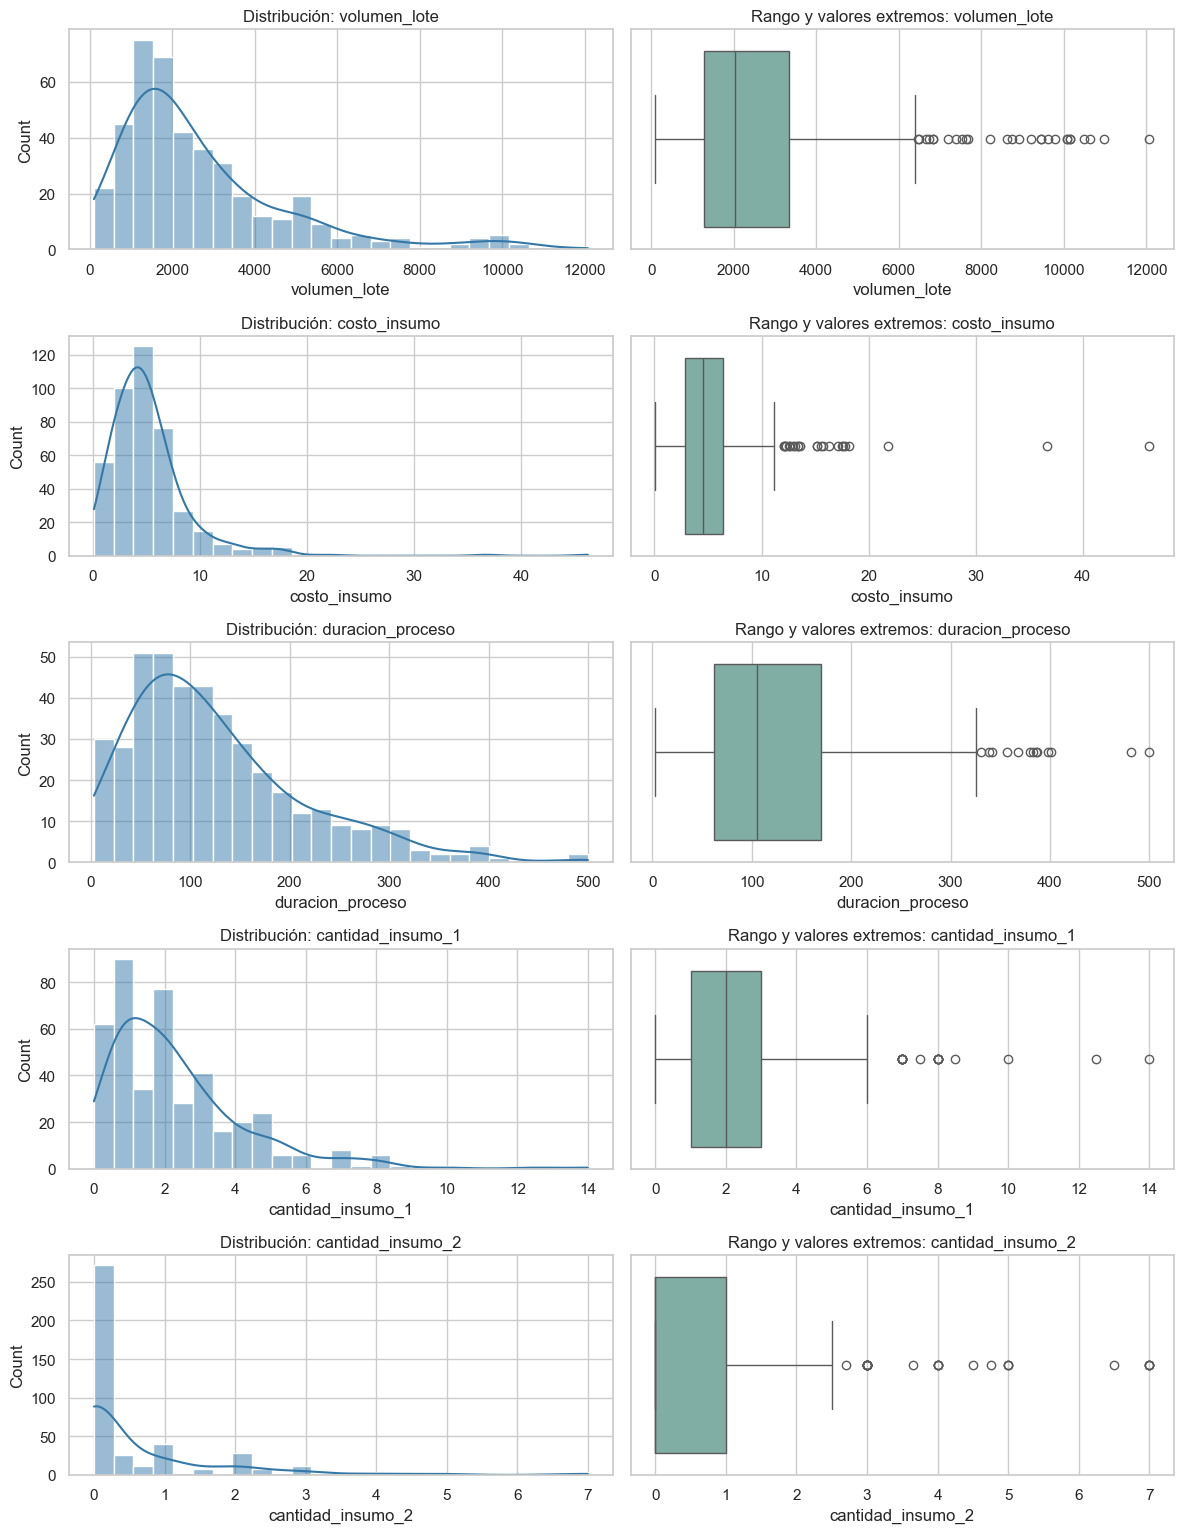

In [6]:
fig, axes = plt.subplots(len(variables_numericas_eda), 2, figsize=(12, 3.1 * len(variables_numericas_eda)))
for fila, variable in enumerate(variables_numericas_eda):
    sns.histplot(data=df, x=variable, bins=25, kde=True, ax=axes[fila, 0], color="#3478a8")
    axes[fila, 0].set(title=f"Distribución: {variable}", xlabel=variable)
    sns.boxplot(data=df, x=variable, ax=axes[fila, 1], color="#79b4a9")
    axes[fila, 1].set(title=f"Rango y valores extremos: {variable}", xlabel=variable)
plt.tight_layout()

Los histogramas y diagramas de caja muestran asimetrías y observaciones alejadas de los rangos centrales, en especial para volumen y costo de insumos. La acumulación de ceros en `cantidad_insumo_2` concuerda con las órdenes de un único insumo. Las marcas de los diagramas justifican revisar casos extremos, pero no bastan para calificarlos como errores ni para excluirlos.

,faltantes_n,faltantes_pct
insumo_2,251,59.34


,ordenes,faltante_insumo_2,pct_faltante
num_insumos,,,
1,251,251,100.0
2,172,0,0.0


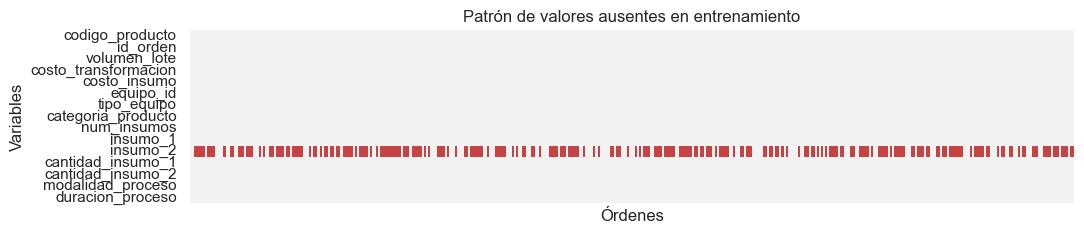

In [7]:
perfil_faltantes = pd.DataFrame({
    "faltantes_n": df.isna().sum(),
    "faltantes_pct": (100 * df.isna().mean()).round(2),
}).query("faltantes_n > 0")
display(perfil_faltantes)

if df.isna().any().any():
    fig, ax = plt.subplots(figsize=(11, 2.5))
    sns.heatmap(df.isna().astype(int).T, cmap=sns.color_palette(["#f2f2f2", "#c74343"]),
                cbar=False, yticklabels=True, xticklabels=False, ax=ax)
    ax.set(title="Patrón de valores ausentes en entrenamiento", xlabel="Órdenes", ylabel="Variables")
    plt.tight_layout()

patron_insumo2 = (df.groupby("num_insumos", dropna=False)
    .agg(ordenes=("insumo_2", "size"), faltante_insumo_2=("insumo_2", lambda s: s.isna().sum()))
    .assign(pct_faltante=lambda t: 100 * t["faltante_insumo_2"] / t["ordenes"]))
display(patron_insumo2.round(2))

La tabla y el mapa de faltantes muestran que las ausencias se limitan a `insumo_2` en órdenes de un insumo. No se observa un patrón de faltantes en las demás variables incluidas. El segundo campo se conserva como categoría ausente para representar la configuración real de la orden.

In [8]:
# Duplicados exactos y configuraciones repetidas, excluyendo el identificador de orden.
columnas_sin_id = [c for c in df.columns if c != "id_orden"]
filas_dup_sin_id = int(df.duplicated(subset=columnas_sin_id).sum())
predictores_config = ["codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
                      "insumo_1", "insumo_2", "modalidad_proceso"]
perfiles_repetidos = df.duplicated(subset=predictores_config, keep=False)
resumen_repeticiones = pd.Series({
    "duplicados_exactos_sin_id": filas_dup_sin_id,
    "órdenes_en_configuraciones_repetidas": int(perfiles_repetidos.sum()),
    "perfiles_de_configuracion_repetidos": int(df.loc[perfiles_repetidos, predictores_config].drop_duplicates().shape[0]),
    "ids_de_orden_duplicados": int(df["id_orden"].duplicated().sum()),
})
display(resumen_repeticiones.to_frame("conteo"))

# Verificar restricciones físicas y valores negativos en el archivo de origen.
controles = {
    "volumen_no_positivo": int((df_original["volumen_lote"] <= 0).sum()),
    "costo_transformacion_negativo": int((df_original[TARGET] < 0).sum()),
    "costo_insumo_negativo": int((pd.to_numeric(df_original["costo_insumo"], errors="coerce") < 0).sum()),
    "duracion_negativa": int((pd.to_numeric(df_original["duracion_proceso"], errors="coerce") < 0).sum()),
    "consumo_insumo_1_negativo": int((pd.to_numeric(df_original["cantidad_insumo_1"], errors="coerce") < 0).sum()),
    "consumo_insumo_2_negativo": int((pd.to_numeric(df_original["cantidad_insumo_2"], errors="coerce") < 0).sum()),
    "num_insumos_fuera_de_0_1_2": int((~df_original["num_insumos"].isin([0, 1, 2])).sum()),
}
display(pd.Series(controles, name="registros").to_frame())

,conteo
duplicados_exactos_sin_id,0
órdenes_en_configuraciones_repetidas,10
perfiles_de_configuracion_repetidos,5
ids_de_orden_duplicados,0


,registros
volumen_no_positivo,5
costo_transformacion_negativo,0
costo_insumo_negativo,0
duracion_negativa,0
consumo_insumo_1_negativo,0
consumo_insumo_2_negativo,0
num_insumos_fuera_de_0_1_2,0


No se detectaron identificadores repetidos ni duplicados exactos al retirar el ID. Se encontraron **10 órdenes** en **5 configuraciones** repetidas; esto puede reflejar órdenes comparables y no duplicación errónea. Los controles no identifican valores negativos en costos, duración o consumos; los cinco volúmenes no positivos ya fueron excluidos. La validación agrupada complementa la prueba aleatoria al evaluar productos no vistos.

In [9]:
filas_outliers = []
for variable in [TARGET] + variables_numericas_eda:
    serie = pd.to_numeric(df[variable], errors="coerce").dropna()
    q1, q3 = serie.quantile([.25, .75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filas_outliers.append({
        "variable": variable, "Q1": q1, "Q3": q3, "limite_inferior": inferior,
        "limite_superior": superior, "n_atipicos_IQR": int(((serie < inferior) | (serie > superior)).sum()),
        "pct_atipicos_IQR": 100 * ((serie < inferior) | (serie > superior)).mean(),
    })
tabla_outliers_iqr = pd.DataFrame(filas_outliers).set_index("variable")
display(tabla_outliers_iqr.round(2))

,Q1,Q3,limite_inferior,limite_superior,n_atipicos_IQR,pct_atipicos_IQR
variable,,,,,,
costo_transformacion,22.21,37.09,-0.09,59.39,18,4.26
volumen_lote,1273.00,3331.00,-1814.00,6418.00,28,6.62
costo_insumo,2.85,6.37,-2.43,11.64,24,5.67
duracion_proceso,62.00,169.50,-99.25,330.75,13,3.07
cantidad_insumo_1,1.00,3.00,-2.00,6.00,19,4.49
cantidad_insumo_2,0.00,1.00,-1.50,2.50,27,6.38


El criterio de 1,5 IQR marca entre **3 % y 7 %** de las observaciones según la variable, con mayor proporción en volumen y cantidades de insumo. Son valores extremos respecto de la distribución de entrenamiento, no necesariamente incorrectos; se conservan sin evidencia de error de registro.

### 3.2 Distribución del costo de transformación

---



In [10]:
y = pd.to_numeric(df[TARGET], errors="coerce").dropna()
resumen_objetivo = pd.DataFrame({
    "estadistico": ["n", "media", "desviación estándar", "mínimo", "Q1", "mediana", "Q3", "P95", "P99", "máximo", "asimetría", "ceros"],
    "valor": [len(y), y.mean(), y.std(ddof=1), y.min(), y.quantile(.25), y.median(), y.quantile(.75),
              y.quantile(.95), y.quantile(.99), y.max(), y.skew(), int((y == 0).sum())],
})
resumen_objetivo["valor"] = resumen_objetivo["valor"].round(2)
display(resumen_objetivo)

,estadistico,valor
0,n,423.00
1,media,30.60
2,desviación estándar,14.83
3,mínimo,2.77
4,Q1,22.21
5,mediana,29.12
6,Q3,37.09
7,P95,56.71
8,P99,80.11
9,máximo,91.72


En las **423 órdenes de entrenamiento**, el costo unitario tiene media de **30,60 COP/unidad**, mediana de **29,12** y desviación estándar de **14,83**. El 50 % central se ubica entre **22,21 y 37,09**; la asimetría es positiva (**1,05**) y el máximo es **91,72 COP/unidad**. La diferencia entre media y mediana y la cola alta indican variación amplia entre órdenes.

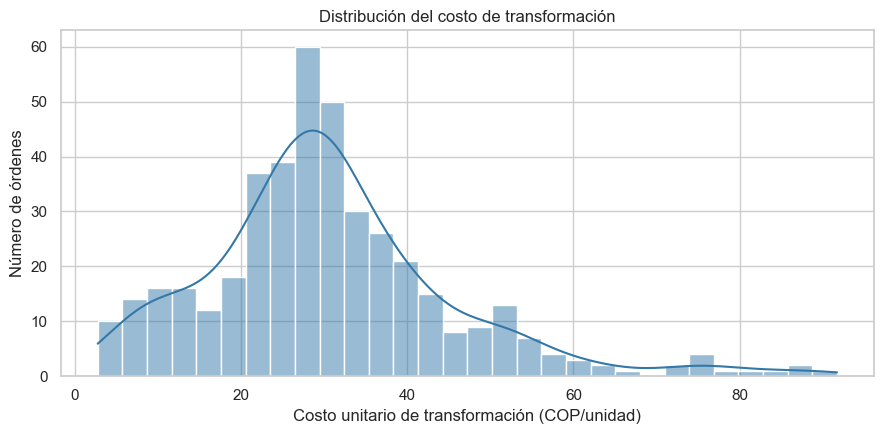

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(y, bins=30, kde=True, ax=ax, color="#3478a8")
ax.set(title="Distribución del costo de transformación", xlabel="Costo unitario de transformación (COP/unidad)", ylabel="Número de órdenes")
plt.tight_layout()

**Prueba de normalidad de la variable objetivo.** Se aplica la prueba de D’Agostino–Pearson, que contrasta conjuntamente asimetría y curtosis. La hipótesis nula establece que la distribución de `costo_transformacion` es normal; la alternativa establece que no lo es. Se usa α = 0,05.

In [12]:
from scipy.stats import normaltest

estadistico_normalidad, p_normalidad = normaltest(y)
print("H₀: la variable objetivo sigue una distribución normal.")
print("H₁: la variable objetivo no sigue una distribución normal.")
print(f"D’Agostino–Pearson: K² = {estadistico_normalidad:.3f}; p = {p_normalidad:.3e}")
print("Decisión (α = 0,05):", "rechazar H₀" if p_normalidad < 0.05 else "no rechazar H₀")

H₀: la variable objetivo sigue una distribución normal.
H₁: la variable objetivo no sigue una distribución normal.
D’Agostino–Pearson: K² = 81.898; p = 1.644e-18
Decisión (α = 0,05): rechazar H₀


D’Agostino–Pearson rechaza la normalidad marginal del costo (K² = **81,898**; p < **0,001**), de acuerdo con la asimetría positiva del histograma. Este contraste describe la respuesta; la normalidad marginal no es un supuesto requerido para ajustar Ridge.

El histograma concentra órdenes en costos intermedios y muestra una cola derecha. La distribución respalda reportar RMSE junto con MAE para comunicar tanto los errores grandes como el error típico en COP/unidad.

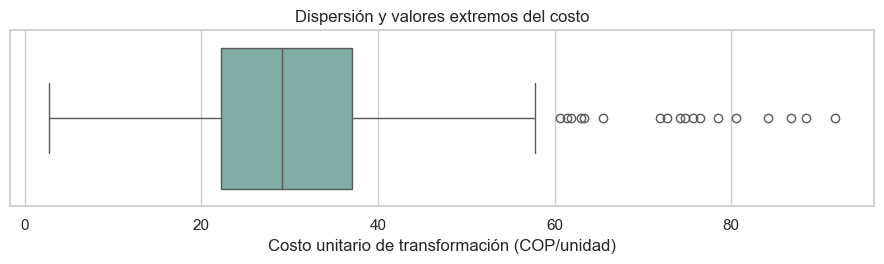

In [13]:
fig, ax = plt.subplots(figsize=(9, 2.8))
sns.boxplot(x=y, ax=ax, color="#79b4a9")
ax.set(title="Dispersión y valores extremos del costo", xlabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

El diagrama de caja destaca valores altos alejados del centro y una dispersión amplia. La regla de los bigotes no distingue por sí sola errores de registro de órdenes costosas; por tanto, no se eliminan observaciones sin confirmación operativa.

### 3.3 Asociaciones con predictores cuantitativos

In [14]:
variables_cuantitativas = [
    "costo_insumo", "duracion_proceso", "volumen_lote",
    "cantidad_insumo_1", "cantidad_insumo_2", "num_insumos",
]
variables_cuantitativas = [c for c in variables_cuantitativas if c in df.columns]
rho = df[[TARGET] + variables_cuantitativas].corr(method="spearman")[TARGET].drop(TARGET)
tabla_rho = (rho.rename("rho_de_Spearman")
             .to_frame()
             .assign(magnitud=lambda z: z["rho_de_Spearman"].abs())
             .sort_values("magnitud", ascending=False)
             .drop(columns="magnitud")
             .round(3))
display(tabla_rho)

,rho_de_Spearman
duracion_proceso,0.325
costo_insumo,0.306
num_insumos,0.291
cantidad_insumo_2,0.266
volumen_lote,-0.216
cantidad_insumo_1,-0.029


En entrenamiento, Spearman es mayor para `duracion_proceso` (ρ = **0,325**), seguida de `costo_insumo` (ρ = **0,306**) y `num_insumos` (ρ = **0,291**). `cantidad_insumo_2` presenta una asociación menor (ρ = **0,266**), `volumen_lote` una asociación negativa (ρ = **−0,216**) y `cantidad_insumo_1` una asociación casi nula (ρ = **−0,029**). Estas relaciones monotónicas son descriptivas, no causales.

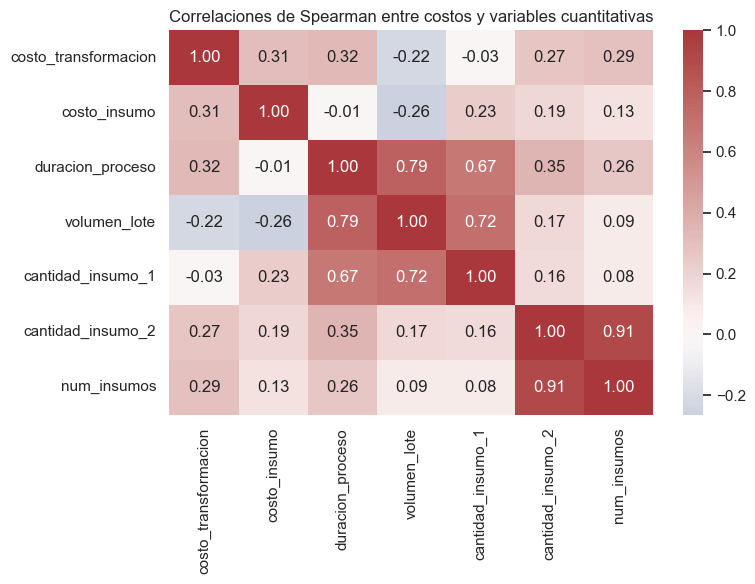

In [15]:
matriz = df[[TARGET] + variables_cuantitativas].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlaciones de Spearman entre costos y variables cuantitativas")
plt.tight_layout()

El mapa de calor muestra dependencias entre predictores además de sus asociaciones con el objetivo. Esta redundancia ayuda a explicar por qué una variable puede mostrar asociación marginal sin aportar información independiente; las correlaciones no se interpretan como efectos separados.

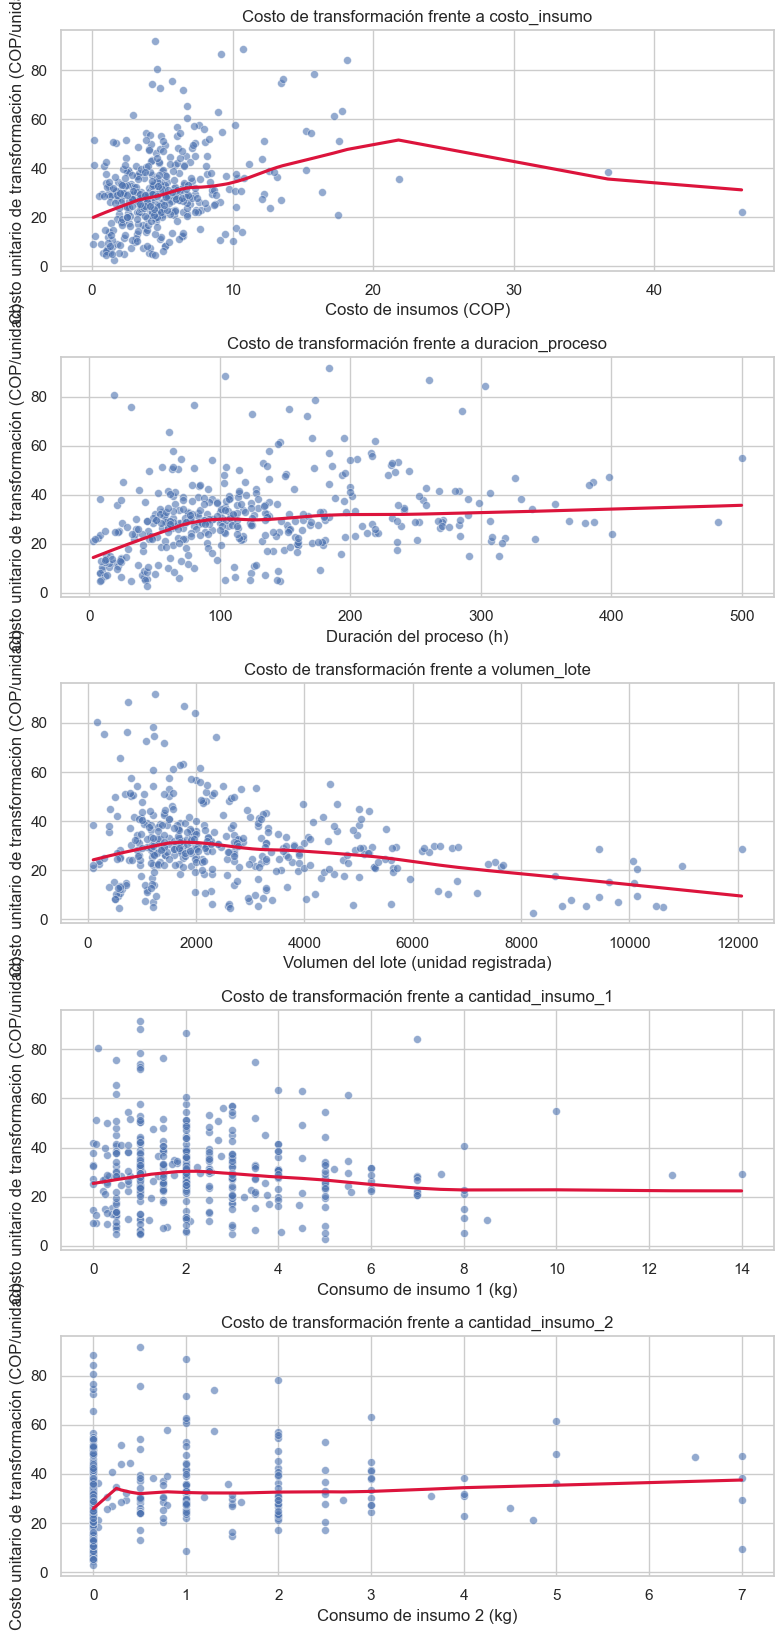

In [16]:
variables_graficos = [
    c for c in ["costo_insumo", "duracion_proceso", "volumen_lote", "cantidad_insumo_1", "cantidad_insumo_2"]
    if c in df.columns
]
fig, axes = plt.subplots(len(variables_graficos), 1, figsize=(8, 3.3 * len(variables_graficos)))
if len(variables_graficos) == 1:
    axes = [axes]
etiquetas_unidad = {"costo_insumo": "Costo de insumos (COP)", "duracion_proceso": "Duración del proceso (h)", "volumen_lote": "Volumen del lote (unidad registrada)", "cantidad_insumo_1": "Consumo de insumo 1 (kg)", "cantidad_insumo_2": "Consumo de insumo 2 (kg)"}
for ax, variable in zip(axes, variables_graficos):
    sns.scatterplot(data=df, x=variable, y=TARGET, alpha=.6, s=32, ax=ax)
    if df[variable].nunique() >= 10:
        sns.regplot(data=df, x=variable, y=TARGET, scatter=False, lowess=True, color="crimson", ax=ax)
    ax.set(title=f"Costo de transformación frente a {variable}", xlabel=etiquetas_unidad.get(variable, variable), ylabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

LOWESS muestra una relación ascendente entre costo y duración y una tendencia negativa con el volumen del lote; la relación con costo de insumos es positiva, aunque dispersa. Las curvas de cantidades consumidas son menos uniformes. Costo de insumos, duración y consumos se observan durante la fabricación, por lo que pueden explicar retrospectivamente el costo, pero no están disponibles al emitir una estimación previa.

### 3.4 Asociaciones entre predictores categóricos

Se examinan relaciones entre variables categóricas de baja cardinalidad para identificar configuraciones que se presentan conjuntamente. Las tablas de contingencia muestran frecuencias observadas; las pruebas χ² y V de Cramér resumen asociación y tamaño de efecto. Para las pruebas con frecuencias esperadas bajas, el valor p asintótico se interpreta con cautela.

,variable_1,variable_2,chi2,gl,p_sin_ajustar,V_Cramer,pct_celdas_esperada_menor_5,p_Holm
0,tipo_equipo,categoria_producto,64.6350,18,3.57e-07,0.2257,64.2857,7.14e-07
1,tipo_equipo,modalidad_proceso,59.5802,6,5.48e-11,0.2654,41.6667,1.64e-10
2,categoria_producto,modalidad_proceso,79.2987,12,5.62e-12,0.3062,47.6190,2.25e-11
3,num_insumos,modalidad_proceso,26.4417,2,1.81e-06,0.2500,16.6667,1.81e-06


categoria_producto,1,2,3,4,5,6,7
tipo_equipo,,,,,,,
A1,7,14,53,26,191,0,27
B2,0,0,0,0,48,1,0
C3,0,0,0,2,5,0,0
D4,0,0,17,0,32,0,0


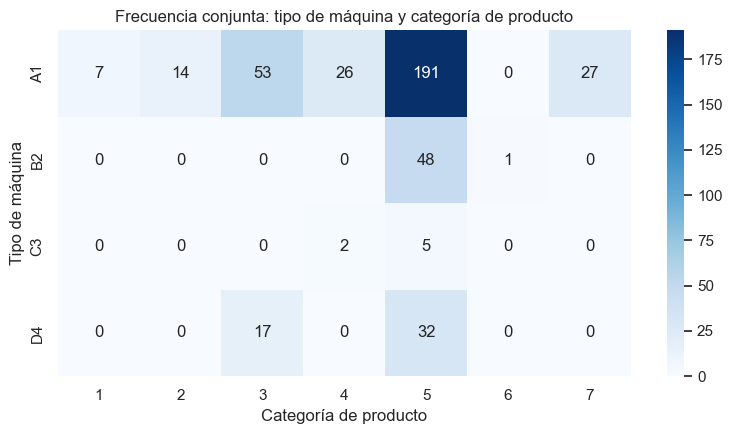

In [17]:
from itertools import combinations
from scipy.stats import chi2_contingency

pares_categoricos = [
    ("tipo_equipo", "categoria_producto"),
    ("tipo_equipo", "modalidad_proceso"),
    ("categoria_producto", "modalidad_proceso"),
    ("num_insumos", "modalidad_proceso"),
]
filas_chi2 = []
for variable_x, variable_y in pares_categoricos:
    tabla = pd.crosstab(df[variable_x], df[variable_y])
    chi2, p, gl, esperadas = chi2_contingency(tabla, correction=False)
    n_tabla = tabla.to_numpy().sum()
    minimo = min(tabla.shape[0] - 1, tabla.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n_tabla * minimo)) if minimo > 0 else np.nan
    filas_chi2.append({
        "variable_1": variable_x, "variable_2": variable_y, "chi2": chi2, "gl": gl,
        "p_sin_ajustar": p, "V_Cramer": v_cramer,
        "pct_celdas_esperada_menor_5": 100 * np.mean(esperadas < 5),
    })
resultados_chi2 = pd.DataFrame(filas_chi2)
# Corrección de Holm para la familia de pruebas categóricas.
pv = resultados_chi2["p_sin_ajustar"].to_numpy()
orden = np.argsort(pv); m = len(pv)
p_adj_orden = np.maximum.accumulate((m - np.arange(m)) * pv[orden])
p_adj = np.empty(m); p_adj[orden] = np.minimum(p_adj_orden, 1)
resultados_chi2["p_Holm"] = p_adj
vista_chi2 = resultados_chi2.copy()
for col in ["p_sin_ajustar", "p_Holm"]:
    vista_chi2[col] = vista_chi2[col].map(lambda valor: f"{valor:.2e}")
display(vista_chi2.round(4))
tabla_tipo_categoria = pd.crosstab(df["tipo_equipo"], df["categoria_producto"])
display(tabla_tipo_categoria)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(tabla_tipo_categoria, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set(title="Frecuencia conjunta: tipo de máquina y categoría de producto", xlabel="Categoría de producto", ylabel="Tipo de máquina")
plt.tight_layout()

La tabla de contingencia y el mapa muestran la asociación más alta entre categoría de producto y modalidad (V de Cramér = **0,306**). Los valores p se ajustaron por Holm. En varios cruces hay muchas celdas con frecuencia esperada inferior a cinco —hasta **64 %**—, por lo que la aproximación χ² es débil; las frecuencias observadas y V de Cramér son más informativas que la significación por sí sola.

### 3.5 Asociación univariada y auditoría preliminar de fuga

La información mutua complementa Spearman y LOWESS porque puede detectar asociaciones no lineales entre predictores y el costo. Se calcula como exploración univariada sobre entrenamiento; los códigos se consideran discretos y sus valores no se interpretan como efectos causales ni como una selección definitiva.

In [18]:
from sklearn.feature_selection import mutual_info_regression

variables_mi = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto", "insumo_1",
    "insumo_2", "modalidad_proceso", "tipo_equipo", "num_insumos", "costo_insumo",
    "duracion_proceso", "cantidad_insumo_1", "cantidad_insumo_2",
]
categoricas_mi = {"codigo_producto", "equipo_id", "categoria_producto", "insumo_1", "insumo_2",
                  "modalidad_proceso", "tipo_equipo", "num_insumos"}
X_mi = pd.DataFrame(index=df.index)
for variable in variables_mi:
    if variable in categoricas_mi:
        X_mi[variable] = pd.factorize(df[variable].astype("object"), sort=True)[0]
    else:
        X_mi[variable] = pd.to_numeric(df[variable], errors="coerce")
discretas_mi = np.array([v in categoricas_mi for v in variables_mi])
mi = mutual_info_regression(X_mi, y=pd.to_numeric(df[TARGET]), discrete_features=discretas_mi,
                            random_state=SEMILLA, n_jobs=1)
tabla_mi = pd.DataFrame({"predictor": variables_mi, "informacion_mutua": mi,
                         "discreto": discretas_mi}).sort_values("informacion_mutua", ascending=False)
display(tabla_mi.round(4))

C:\Users\Work\miniconda3\envs\project-env\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Work\miniconda3\envs\project-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Work\miniconda3\envs\project-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Work\miniconda3\envs\project-env\Lib\subprocess.py", line 554, in run
    with P

,predictor,informacion_mutua,discreto
0,codigo_producto,0.5755,True
7,tipo_equipo,0.3053,True
2,equipo_id,0.3033,True
10,duracion_proceso,0.2017,False
1,volumen_lote,0.1908,False
5,insumo_2,0.1449,True
4,insumo_1,0.1351,True
9,costo_insumo,0.1045,False
3,categoria_producto,0.0774,True
11,cantidad_insumo_1,0.0772,False


La información mutua es mayor para `codigo_producto` (MI = **0,576**), seguida de `tipo_equipo` y `equipo_id` (≈ **0,30**). Entre las variables numéricas, duración y volumen muestran señal moderada. La información mutua no expresa un efecto ni el aporte incremental al modelo. Las variables observadas durante la ejecución se excluyen del modelo operativo porque no estarían disponibles al predecir.

### 3.6 Estructura multivariada y observaciones atípicas

El PCA se aplica al bloque numérico continuo estandarizado, sin objetivo ni identificadores. Su función es descriptiva: resumir covariación y detectar concentración o separación de observaciones. Isolation Forest se usa como detector exploratorio de anomalías en ese bloque; sus marcas no se eliminan automáticamente.

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.497,0.497
1,PC2,0.239,0.736
2,PC3,0.162,0.898
3,PC4,0.055,0.953
4,PC5,0.047,1.000


Observaciones marcadas por Isolation Forest: 62 de 423


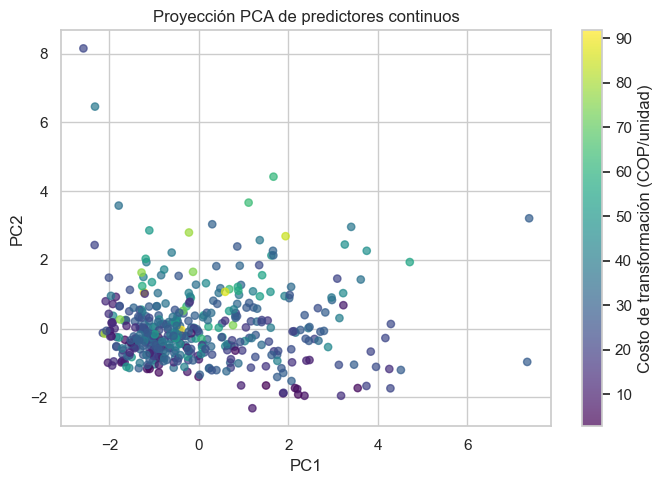

In [19]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

variables_pca = ["volumen_lote", "costo_insumo", "duracion_proceso",
                 "cantidad_insumo_1", "cantidad_insumo_2"]
X_continuo = df[variables_pca].apply(pd.to_numeric, errors="coerce")
X_continuo = X_continuo.fillna(X_continuo.median())
Z_pca = StandardScaler().fit_transform(X_continuo)
pca = PCA().fit(Z_pca)
varianza_pca = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_),
})
display(varianza_pca.round(3))
coords_pca = PCA(n_components=2).fit_transform(Z_pca)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(coords_pca[:, 0], coords_pca[:, 1], c=df[TARGET], cmap="viridis", alpha=.7, s=28)
fig.colorbar(sc, ax=ax, label="Costo de transformación (COP/unidad)")
ax.set(title="Proyección PCA de predictores continuos", xlabel="PC1", ylabel="PC2")
plt.tight_layout()

iforest = IsolationForest(contamination="auto", random_state=SEMILLA)
etiquetas_anomalia = iforest.fit_predict(Z_pca)
print(f"Observaciones marcadas por Isolation Forest: {(etiquetas_anomalia == -1).sum()} de {len(df)}")

Las dos primeras componentes del PCA explican **73,6 %** de la variabilidad numérica (**49,7 %** y **23,9 %**). La proyección resume covariación, pero no incorpora categorías ni demuestra separación de costos. Isolation Forest marca **62 de 423 órdenes (14,7 %)** como relativamente aisladas; esto orienta la revisión, no la exclusión automática.

### 3.7 Heterogeneidad por equipo y configuración de producción

In [20]:
variables_grupo = ["tipo_equipo", "equipo_id", "modalidad_proceso", "num_insumos"]
filas = []
for variable in variables_grupo:
    tabla = df.groupby(variable, dropna=False)[TARGET].agg(n="count", media="mean", mediana="median", desv_std="std")
    for categoria, estadisticos in tabla.iterrows():
        filas.append({"variable": variable, "categoria": categoria, **estadisticos.to_dict()})
tabla_grupos = pd.DataFrame(filas).sort_values(["variable", "n"], ascending=[True, False])
display(tabla_grupos.round(2))

,variable,categoria,n,media,mediana,desv_std
14,equipo_id,M16,52.0,33.14,29.09,15.09
12,equipo_id,M14,51.0,33.27,30.54,13.03
15,equipo_id,M17,50.0,31.75,30.07,14.43
4,equipo_id,M02,49.0,30.34,28.18,11.25
8,equipo_id,M09,48.0,34.66,31.61,14.37
13,equipo_id,M15,47.0,36.71,34.30,10.44
11,equipo_id,M13,40.0,29.11,28.72,9.55
6,equipo_id,M05,32.0,11.13,10.94,3.85
7,equipo_id,M08,30.0,31.33,29.32,8.30
10,equipo_id,M12,17.0,7.28,7.12,2.48


En la tabla, `M04` y `M11` presentan medias altas, pero solo cuentan con **3** y **4 órdenes**, por lo que sus estimaciones son inestables. Las modalidades X e Y, más frecuentes, tienen medias próximas (**29,41** y **31,56 COP/unidad**); Z contiene solo 10 órdenes. Las órdenes con dos insumos tienen mayor media que las de uno (**35,26** frente a **27,41 COP/unidad**). Estas diferencias pueden reflejar mezclas distintas de productos y equipos. En el tipo de máquina, `A1` reúne 318 órdenes, `B2` y `D4` 49 cada uno, y `C3` solo 7; su media alta debe leerse con esa baja frecuencia.

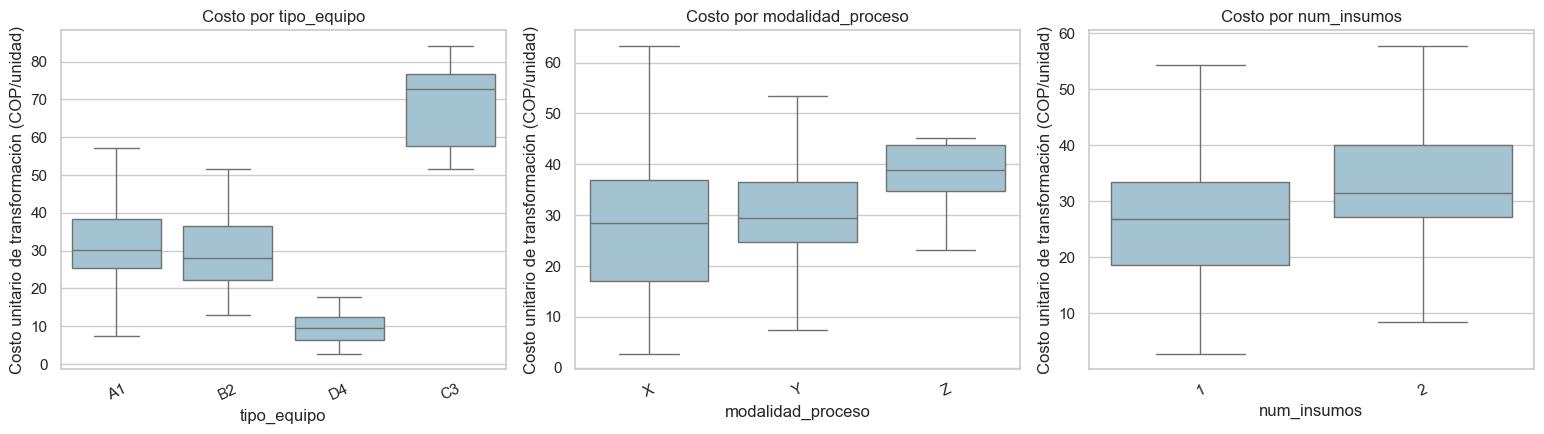

In [21]:
variables_caja = ["tipo_equipo", "modalidad_proceso", "num_insumos"]
fig, axes = plt.subplots(1, len(variables_caja), figsize=(5.2 * len(variables_caja), 4.5))
for ax, variable in zip(axes, variables_caja):
    orden = df[variable].value_counts().index
    sns.boxplot(data=df, x=variable, y=TARGET, order=orden, showfliers=False, ax=ax, color="#9bc6d9")
    ax.set(title=f"Costo por {variable}", xlabel=variable, ylabel="Costo unitario de transformación (COP/unidad)")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

Los diagramas de caja y puntos muestran amplia dispersión dentro de X e Y y costos medios más altos para las órdenes de dos insumos. Entre tipos de máquina, `D4` presenta costos bajos y `C3` altos, con menor precisión para este último por sus siete órdenes. El solapamiento dentro de los grupos indica que ninguna categoría por sí sola determina el costo.

### 3.8 Diferencias descriptivas según categoría de producto

`categoria_producto` se analiza como variable categórica nominal: sus códigos identifican grupos, pero no representan una escala ordenada. Como no se dispone de un diccionario que traduzca los códigos a familias de producto, las categorías se presentan por su código. La tabla resume el tamaño y la distribución del costo unitario de transformación (COP/unidad) en cada grupo.

In [22]:
tabla_categoria_producto = (df.groupby("categoria_producto")[TARGET]
    .agg(n="count", media="mean", desviacion="std", mediana="median",
         Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75))
    .assign(proporcion=lambda t: 100 * t["n"] / t["n"].sum())
    .sort_index())
display(tabla_categoria_producto.round(2))

,n,media,desviacion,mediana,Q1,Q3,proporcion
categoria_producto,,,,,,,
1,7,26.28,7.09,28.64,24.46,30.34,1.65
2,14,37.72,18.87,32.28,30.98,38.11,3.31
3,70,21.71,12.64,21.77,11.44,29.29,16.55
4,28,33.35,9.51,29.98,27.16,36.31,6.62
5,276,31.65,15.26,29.37,22.48,38.35,65.25
6,1,50.22,NaN,50.22,50.22,50.22,0.24
7,27,36.75,9.10,36.22,29.32,41.39,6.38


La categoría 5 reúne **276 órdenes (65,3 %)** y la categoría 6 solo una. Las medianas y los rangos intercuartílicos varían entre grupos; una observación no permite estimar dispersión ni sustentar conclusiones sobre la categoría 6.

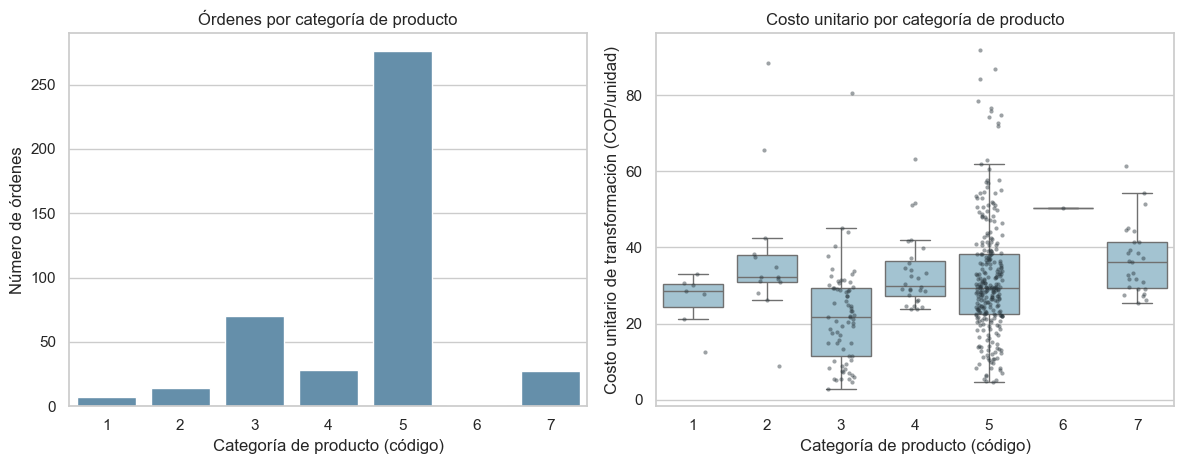

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
orden_categorias = sorted(df["categoria_producto"].dropna().unique())
conteos_categoria = df["categoria_producto"].value_counts().reindex(orden_categorias, fill_value=0)
sns.barplot(x=conteos_categoria.index.astype(str), y=conteos_categoria.values, ax=axes[0], color="#5a91b5")
axes[0].set(title="Órdenes por categoría de producto", xlabel="Categoría de producto (código)", ylabel="Número de órdenes")
sns.boxplot(data=df, x="categoria_producto", y=TARGET, order=orden_categorias,
            showfliers=False, ax=axes[1], color="#9bc6d9")
sns.stripplot(data=df, x="categoria_producto", y=TARGET, order=orden_categorias,
              color="#263238", alpha=.45, size=3, jitter=.18, ax=axes[1])
axes[1].set(title="Costo unitario por categoría de producto", xlabel="Categoría de producto (código)", ylabel="Costo unitario de transformación (COP/unidad)")
plt.tight_layout()

El gráfico de frecuencias muestra la concentración en la categoría 5; el diagrama de costos evidencia heterogeneidad en las categorías más numerosas. La posición de la categoría 6 corresponde a una sola orden y no se puede separar de la variación individual.

In [24]:
from scipy.stats import kruskal

muestras_categoria = [g[TARGET].dropna().to_numpy() for _, g in df.groupby("categoria_producto")]
H_kruskal, p_kruskal = kruskal(*muestras_categoria)
n_kw = sum(map(len, muestras_categoria))
k_kw = len(muestras_categoria)
epsilon2_kruskal = max(0, (H_kruskal - k_kw + 1) / (n_kw - k_kw))
print(f"Kruskal-Wallis: H={H_kruskal:.3f}; gl={k_kw-1}; p={p_kruskal:.3e}")
print(f"Tamaño de efecto epsilon-cuadrado: {epsilon2_kruskal:.3f}")

Kruskal-Wallis: H=48.924; gl=6; p=7.721e-09
Tamaño de efecto epsilon-cuadrado: 0.103


Kruskal–Wallis detecta diferencias globales entre categorías de producto (H = **48,924**; gl = 6; p < **0,001**; ε² = **0,103**). El contraste no indica qué pares difieren; el desbalance y los grupos pequeños aconsejan cautela.

### 3.9 Frecuencia de órdenes por producto

La frecuencia de `codigo_producto` permite evaluar cuántas órdenes respaldan la estimación para cada producto. Se resume la distribución de órdenes por código y se muestran los 15 productos con mayor representación. El análisis usa el conjunto de desarrollo para mantener coherencia con el EDA.

,n_productos,proporcion_productos_pct,proporcion_ordenes_pct
count,,,
1,65,49.24,15.37
2,22,16.67,10.40
3,15,11.36,10.64
4,7,5.30,6.62
5,5,3.79,5.91
6,3,2.27,4.26
7,6,4.55,9.93
8,2,1.52,3.78
9,2,1.52,4.26


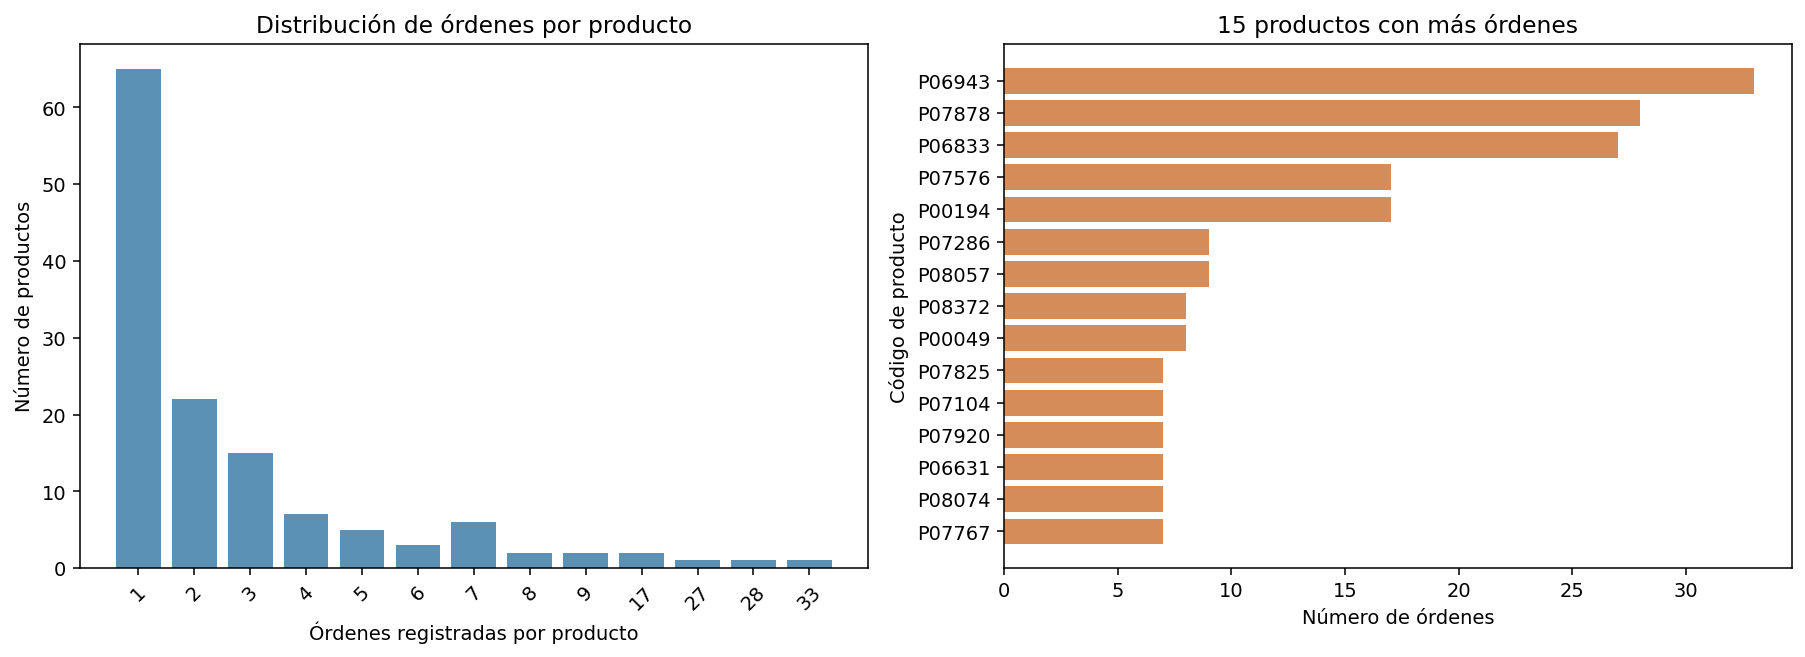

codigo_producto,n_ordenes
P06943,33
P07878,28
P06833,27
P07576,17
P00194,17
P07286,9
P08057,9
P08372,8
P00049,8
P07825,7


In [ ]:
# Frecuencia de órdenes por producto en el conjunto de desarrollo.
frecuencia_productos = df["codigo_producto"].astype(str).value_counts()
distribucion_frecuencia = frecuencia_productos.value_counts().sort_index()
tabla_frecuencia_productos = pd.DataFrame({
    "n_productos": distribucion_frecuencia,
    "proporcion_productos_pct": 100 * distribucion_frecuencia / distribucion_frecuencia.sum(),
    "proporcion_ordenes_pct": 100 * distribucion_frecuencia.index.to_numpy() * distribucion_frecuencia.to_numpy() / len(df),
})
tabla_frecuencia_productos.index.name = "ordenes_por_producto"
tabla_frecuencia_productos["proporcion_ordenes_pct"] = tabla_frecuencia_productos["proporcion_ordenes_pct"].round(2)
display(tabla_frecuencia_productos.round(2))

top_productos = frecuencia_productos.head(15).rename_axis("codigo_producto").reset_index(name="n_ordenes")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(distribucion_frecuencia.index.astype(str), distribucion_frecuencia.values, color="#5a91b5")
axes[0].set(title="Distribución de órdenes por producto", xlabel="Órdenes registradas por producto", ylabel="Número de productos")
axes[0].tick_params(axis="x", rotation=45)
axes[1].barh(top_productos["codigo_producto"].astype(str).iloc[::-1], top_productos["n_ordenes"].iloc[::-1], color="#d58c58")
axes[1].set(title="15 productos con más órdenes", xlabel="Número de órdenes", ylabel="Código de producto")
plt.tight_layout()
display(fig)
plt.close(fig)
display(top_productos)


La frecuencia está concentrada y es desigual: **65 de 132 productos (49.2 %) aparecen en una sola orden**; la mediana es **2 órdenes** y el máximo, **33**. Los diez productos más frecuentes reúnen **163 órdenes (38.5 % del conjunto de desarrollo)**. Por tanto, la señal asociada a `codigo_producto` tiene soporte muy distinto entre niveles: para muchos códigos hay poca información para estimar patrones propios, mientras que unos pocos productos influyen más en el ajuste. Esto contextualiza la brecha entre validación aleatoria y agrupada; la frecuencia por sí sola no demuestra sobreajuste, pero ayuda a explicar por qué la transferencia a productos no observados es exigente.

## 4. Ridge ampliado como diagnóstico

Este Ridge incluye las variables disponibles salvo `id_orden`, entre ellas `duracion_proceso`, `costo_insumo` y los consumos reales. Por tanto, evalúa una pregunta posterior a la ejecución y no constituye el estimador operativo definido en la sección 5.

La selección de α se realiza mediante validación interna sobre el pipeline completo: imputación, escalamiento y codificación se ajustan dentro de cada pliegue. En validación agrupada, también se agrupan los pliegues internos por código de producto. Se comparan validación aleatoria repetida de 5 pliegues y 3 repeticiones con validación externa agrupada por `codigo_producto`. La referencia predice la media del costo de entrenamiento.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ALPHAS = np.logspace(-3, 5, 17)

def construir_pipeline_ridge(X):
    categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()
    # categoria_producto es un código entero nominal, no una escala cuantitativa.
    if "categoria_producto" in X.columns and "categoria_producto" not in categoricas:
        categoricas.append("categoria_producto")
    numericas = [columna for columna in X.columns if columna not in categoricas]
    preprocesamiento = ColumnTransformer([
        ("numericas", Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("estandarizar", StandardScaler()),
        ]), numericas),
        ("categoricas", Pipeline([
            ("imputar", SimpleImputer(strategy="most_frequent")),
            ("indicadores", OneHotEncoder(handle_unknown="ignore")),
        ]), categoricas),
    ])
    return Pipeline([("preprocesamiento", preprocesamiento), ("ridge", Ridge())])

def evaluar_ridge_anidado(X, y, pliegues_externos, esquema, grupos=None, etiqueta="Ridge"):
    """Ajusta todo el pipeline en los pliegues internos y evalúa en pliegues externos."""
    filas = []
    for pliegue, (idx_train, idx_test) in enumerate(pliegues_externos, start=1):
        if esquema == "agrupada":
            grupos_train = grupos.iloc[idx_train]
            cv_interna = GroupKFold(n_splits=3)
        else:
            grupos_train = None
            cv_interna = KFold(n_splits=3, shuffle=True, random_state=17)
        busqueda = GridSearchCV(
            estimator=construir_pipeline_ridge(X.iloc[idx_train]),
            param_grid={"ridge__alpha": ALPHAS},
            scoring="neg_mean_squared_error",
            cv=cv_interna,
            n_jobs=1,
            refit=True,
        )
        busqueda.fit(
            X.iloc[idx_train], y.iloc[idx_train],
            **({"groups": grupos_train} if grupos_train is not None else {}),
        )
        pred = busqueda.predict(X.iloc[idx_test])
        media = np.full(len(idx_test), y.iloc[idx_train].mean())
        for modelo, estimado in [(etiqueta, pred), ("Media de entrenamiento", media)]:
            filas.append({
                "validacion": esquema,
                "pliegue": pliegue,
                "modelo": modelo,
                "RMSE": np.sqrt(mean_squared_error(y.iloc[idx_test], estimado)),
                "MAE": mean_absolute_error(y.iloc[idx_test], estimado),
                "R_cuadrado": r2_score(y.iloc[idx_test], estimado),
                "alpha": busqueda.best_params_["ridge__alpha"] if modelo == etiqueta else np.nan,
            })
    return pd.DataFrame(filas)

TARGET = "costo_transformacion"
y_modelo = pd.to_numeric(df[TARGET], errors="coerce")
X_ampliado = df.drop(columns=[TARGET, "id_orden"]).copy()
grupos_producto = df["codigo_producto"].astype(str)
pliegues_aleatorios = list(RepeatedKFold(n_splits=5, n_repeats=3, random_state=42).split(X_ampliado, y_modelo))
pliegues_producto = list(GroupKFold(n_splits=5).split(X_ampliado, y_modelo, groups=grupos_producto))

resultados_ampliado = pd.concat([
    evaluar_ridge_anidado(X_ampliado, y_modelo, pliegues_aleatorios, "aleatoria", etiqueta="Ridge ampliado"),
    evaluar_ridge_anidado(X_ampliado, y_modelo, pliegues_producto, "agrupada", grupos=grupos_producto, etiqueta="Ridge ampliado"),
], ignore_index=True)
tabla_modelo = (resultados_ampliado
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .agg(["mean", "std"]).round(2))
display(tabla_modelo)

RMSE          MAE       R_cuadrado      
                                    mean   std   mean   std       mean   std
validacion modelo                                                           
agrupada   Media de entrenamiento  14.85  3.02  10.89  3.09      -0.09  0.06
           Ridge ampliado           9.87  1.85   6.92  1.25       0.51  0.04
aleatoria  Media de entrenamiento  14.79  1.21  10.67  0.92      -0.01  0.01
           Ridge ampliado           8.79  0.96   6.04  0.58       0.64  0.05

El Ridge ampliado supera a la media también en validación aleatoria (RMSE = **8,79**, R² = **0,64**) y agrupada por producto (RMSE = **9,87**, R² = **0,51**). Sin embargo, incluye costo de insumos, duración y consumos medidos durante la fabricación. La mejora caracteriza una explicación retrospectiva del costo y no el desempeño disponible al definir la orden; por eso se mantiene como diagnóstico, no como modelo operativo.

## 5. Modelo basado en la configuración de la orden

El modelo operativo se limita a variables conocidas al definir la orden: producto, volumen, equipo, insumos y modalidad. Se excluyen duración, costo de insumos y cantidades consumidas porque describen la ejecución real; incluirlas cambiaría la pregunta a una explicación retrospectiva del costo.

### 5.1 Selección de predictores

La especificación principal (A) prioriza variables disponibles al definir la orden. Las especificaciones A y B permiten evaluar variables con información solapada sin asumir de antemano que sean inútiles.

| Variable | Especificación A | Criterio |
|---|---:|---|
| `codigo_producto` | Sí | Identifica el producto específico. |
| `categoria_producto` | Sí | Describe una agrupación distinta del código específico; su distribución y su asociación con el costo se exploran en la sección 3.8. |
| `volumen_lote` | Sí | Representa la escala de la orden; su unidad no está especificada. |
| `equipo_id` | Sí | Identifica el equipo individual asignado. |
| `tipo_equipo` | No; se añade en B | Está relacionado con `equipo_id`, pero describe su familia. La sección 3.7 muestra diferencias entre tipos; por eso se evalúa en B en vez de descartarlo como irrelevante. |
| `insumo_1`, `insumo_2` | Sí | Describen la composición de insumos; la ausencia de `insumo_2` es estructural en órdenes de un insumo. |
| `num_insumos` | No; se añade en B | Resume la configuración ya reflejada parcialmente por los campos de insumo; se evalúa conjuntamente con `tipo_equipo`. |
| `modalidad_proceso` | Sí | Describe la modalidad prevista de operación. |
| `duracion_proceso`, `costo_insumo`, cantidades consumidas | No | Son resultados observados durante o después de la ejecución. |
| `periodo`, `id_orden` | No | Se excluyen el tiempo y el identificador; ninguno forma parte de la pregunta operativa. |

La comparación A/B evalúa el aporte conjunto de `tipo_equipo` y `num_insumos`; no permite atribuir la diferencia a uno de ellos por separado.

In [29]:
TARGET = "costo_transformacion"

FEATURES_A = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
    "insumo_1", "insumo_2", "modalidad_proceso",
]
FEATURES_REDUNDANTES = ["tipo_equipo", "num_insumos"]
FEATURES_B = FEATURES_A + FEATURES_REDUNDANTES

print("Variable objetivo:", TARGET)
print("Modelo A: características seleccionadas, sin las variables consideradas redundantes")
print("Modelo B: mismas características más tipo_equipo y num_insumos")
print("Predictores redundantes añadidos:", FEATURES_REDUNDANTES)

Variable objetivo: costo_transformacion
Modelo A: características seleccionadas, sin las variables consideradas redundantes
Modelo B: mismas características más tipo_equipo y num_insumos
Predictores redundantes añadidos: ['tipo_equipo', 'num_insumos']


### Auditoría univariada de posibles proxies

Como diagnóstico de fuga, se compara el desempeño de modelos univariados agrupados por producto. Las variables de ejecución se contrastan con las variables disponibles al definir la orden. Una asociación univariada alta es una señal para revisar disponibilidad y proximidad conceptual al objetivo, no una prueba automática de fuga.

In [30]:
from sklearn.model_selection import cross_val_score

variables_auditoria = [
    "codigo_producto", "categoria_producto", "volumen_lote", "equipo_id", "tipo_equipo",
    "insumo_1", "insumo_2", "num_insumos", "modalidad_proceso", "costo_insumo",
    "duracion_proceso", "cantidad_insumo_1", "cantidad_insumo_2",
]
y_auditoria = pd.to_numeric(df[TARGET], errors="coerce")
grupos_auditoria = df["codigo_producto"].astype(str)
cv_auditoria = GroupKFold(n_splits=5)
filas_auditoria = []
for variable in variables_auditoria:
    estimador = construir_pipeline_ridge(df[[variable]]).set_params(ridge__alpha=1.0)
    puntuaciones = cross_val_score(
        estimador, df[[variable]], y_auditoria, groups=grupos_auditoria,
        cv=cv_auditoria, scoring="r2", n_jobs=1,
    )
    filas_auditoria.append({
        "variable": variable,
        "disponible_al_especificar_orden": variable not in {
            "costo_insumo", "duracion_proceso", "cantidad_insumo_1", "cantidad_insumo_2"
        },
        "R2_CV_agrupada_media": puntuaciones.mean(),
        "R2_CV_agrupada_desv": puntuaciones.std(ddof=1),
    })
resultado_auditoria = pd.DataFrame(filas_auditoria).sort_values("R2_CV_agrupada_media", ascending=False)
display(resultado_auditoria.round(3))

,variable,disponible_al_especificar_orden,R2_CV_agrupada_media,R2_CV_agrupada_desv
4,tipo_equipo,True,0.205,0.241
3,equipo_id,True,0.065,0.133
9,costo_insumo,False,-0.002,0.094
2,volumen_lote,True,-0.017,0.058
10,duracion_proceso,False,-0.031,0.085
1,categoria_producto,True,-0.057,0.102
7,num_insumos,True,-0.061,0.135
12,cantidad_insumo_2,False,-0.063,0.065
5,insumo_1,True,-0.063,0.072
0,codigo_producto,True,-0.084,0.083


La tabla ayuda a identificar predictores cuya señal depende de resultados observados durante la ejecución. Se utiliza la misma agrupación por producto para impedir que el código de un producto aparezca en ambos lados de cada pliegue. Los R² univariados son diagnósticos de disponibilidad/proxy, no comparaciones causales ni pruebas del aporte incremental al modelo multivariable.

### 5.2 Comparación de especificaciones a la luz del EDA

El EDA muestra heterogeneidad del costo entre categorías de producto y máquina. La categoría 6 contiene una orden y el tipo `C3`, siete; sus estimaciones son inciertas. `equipo_id` y `tipo_equipo` representan niveles relacionados. Ridge B añade `tipo_equipo` y `num_insumos` conjuntamente, por lo que la comparación no permite atribuir la diferencia a una variable por separado.

In [31]:
X_A = df[FEATURES_A].copy()
X_B = df[FEATURES_B].copy()
y_modelo_new = pd.to_numeric(df[TARGET], errors="coerce")

resultados_comparacion = []
for nombre, X_especificacion in [("A: sin redundantes", X_A), ("B: con redundantes", X_B)]:
    resultados_comparacion.append(evaluar_ridge_anidado(
        X_especificacion, y_modelo_new, pliegues_aleatorios, "aleatoria", etiqueta=nombre
    ))
    resultados_comparacion.append(evaluar_ridge_anidado(
        X_especificacion, y_modelo_new, pliegues_producto, "agrupada",
        grupos=grupos_producto, etiqueta=nombre
    ))
resultados_comparacion = pd.concat(resultados_comparacion, ignore_index=True)
# La referencia de la media es idéntica en A y B; conservar una sola copia por pliegue.
resultados_comparacion = resultados_comparacion.drop_duplicates(
    subset=["validacion", "pliegue", "modelo"]
)
tabla_comparacion = (resultados_comparacion
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .agg(["mean", "std"]).round(2))
display(tabla_comparacion)

# Diferencia media de las métricas para valorar el aporte de las variables añadidas.
resumen_comparacion = (resultados_comparacion
    .groupby(["validacion", "modelo"])[["RMSE", "MAE", "R_cuadrado"]]
    .mean().round(3).reset_index())
display(resumen_comparacion)
# Diferencias pareadas B − A sobre los mismos pliegues externos.
metricas_pareadas = []
for metrica in ["RMSE", "MAE", "R_cuadrado"]:
    ancho = (resultados_comparacion[resultados_comparacion["modelo"].isin(["A: sin redundantes", "B: con redundantes"])]
        .pivot(index=["validacion", "pliegue"], columns="modelo", values=metrica))
    delta = ancho["B: con redundantes"] - ancho["A: sin redundantes"]
    tmp = delta.rename(f"delta_B_menos_A_{metrica}").reset_index()
    metricas_pareadas.append(tmp)
diferencias_plegadas = metricas_pareadas[0]
for tmp in metricas_pareadas[1:]:
    diferencias_plegadas = diferencias_plegadas.merge(tmp, on=["validacion", "pliegue"])
columnas_delta = [col for col in diferencias_plegadas.columns if col.startswith("delta_")]
tabla_diferencias = (diferencias_plegadas.groupby("validacion")[columnas_delta]
    .agg(["mean", "std"]).round(3))
display(tabla_diferencias)

RMSE          MAE       R_cuadrado      
                                    mean   std   mean   std       mean   std
validacion modelo                                                           
agrupada   A: sin redundantes      12.64  1.50   9.12  0.84       0.19  0.11
           B: con redundantes      11.81  1.47   8.57  0.70       0.26  0.22
           Media de entrenamiento  14.85  3.02  10.89  3.09      -0.09  0.06
aleatoria  A: sin redundantes      11.08  0.99   7.66  0.52       0.43  0.07
           B: con redundantes      10.74  0.98   7.50  0.53       0.46  0.09
           Media de entrenamiento  14.79  1.21  10.67  0.92      -0.01  0.01

,validacion,modelo,RMSE,MAE,R_cuadrado
0,agrupada,A: sin redundantes,12.640,9.122,0.185
1,agrupada,B: con redundantes,11.810,8.568,0.261
2,agrupada,Media de entrenamiento,14.854,10.890,-0.093
3,aleatoria,A: sin redundantes,11.076,7.662,0.431
4,aleatoria,B: con redundantes,10.745,7.501,0.462
5,aleatoria,Media de entrenamiento,14.791,10.672,-0.009


delta_B_menos_A_RMSE        delta_B_menos_A_MAE         \
                           mean    std                mean    std   
validacion                                                          
agrupada                 -0.830  1.377              -0.554  1.102   
aleatoria                -0.332  0.387              -0.161  0.273   

           delta_B_menos_A_R_cuadrado         
                                 mean    std  
validacion                                    
agrupada                        0.076  0.116  
aleatoria                       0.032  0.038

Los resultados de validación cruzada muestran que Ridge B reduce el error medio frente a A. En validación aleatoria, B alcanza RMSE **10,75** y R² **0,462**, frente a **11,08** y **0,431** para A; este esquema estima predicciones de órdenes nuevas de productos potencialmente conocidos. En validación agrupada, B obtiene RMSE **11,81** y R² **0,261**, frente a **12,64** y **0,185** para A; esta comparación evalúa productos no vistos. La diferencia entre esquemas indica que transferir el modelo a productos nuevos es más difícil.

#### Prueba pareada del incremento en R²

Para cada pliegue externo, la diferencia se calcula como:

$$
\Delta_i = R^2_{B,i} - R^2_{A,i}
$$

Las hipótesis son:

$$
H_0: \mu_{\Delta R^2} \leq 0
$$

$$
H_1: \mu_{\Delta R^2} > 0
$$

Se aplica la prueba t corregida de Nadeau–Bengio porque los conjuntos de entrenamiento de los pliegues se superponen. Se usa una prueba unilateral con $\alpha=0,05$ y los dos valores p se ajustan mediante Holm. El contraste es aproximado y la validación agrupada comprende solo cinco pliegues.

In [32]:
from scipy.stats import t as distribucion_t

pruebas_r2 = []
for esquema, pliegues in [("aleatoria", pliegues_aleatorios), ("agrupada", pliegues_producto)]:
    diferencias = diferencias_plegadas.loc[
        diferencias_plegadas["validacion"] == esquema,
        "delta_B_menos_A_R_cuadrado"
    ].dropna().to_numpy()
    n = len(diferencias)
    media_delta = diferencias.mean()
    sd_delta = diferencias.std(ddof=1)
    razon_test_train = np.mean([len(test) / len(train) for train, test in pliegues])
    error_estandar_corregido = sd_delta * np.sqrt(1 / n + razon_test_train)
    estadistico_t = media_delta / error_estandar_corregido
    grados_libertad = n - 1
    p_unilateral = distribucion_t.sf(estadistico_t, df=grados_libertad)
    t_critico = distribucion_t.ppf(.975, df=grados_libertad)
    pruebas_r2.append({
        "validacion": esquema,
        "pliegues_pareados": n,
        "delta_R2_B_menos_A": media_delta,
        "desv_std_delta": sd_delta,
        "t_corregida": estadistico_t,
        "gl": grados_libertad,
        "p_unilateral": p_unilateral,
        "IC95_inf": media_delta - t_critico * error_estandar_corregido,
        "IC95_sup": media_delta + t_critico * error_estandar_corregido,
        "razon_prueba_entrenamiento": razon_test_train,
    })

prueba_r2 = pd.DataFrame(pruebas_r2)
# Ajuste de Holm para las dos hipótesis predefinidas (aleatoria y agrupada).
p_sin_ajustar = prueba_r2["p_unilateral"].to_numpy()
orden_p = np.argsort(p_sin_ajustar)
m = len(p_sin_ajustar)
p_holm_ordenadas = np.maximum.accumulate((m - np.arange(m)) * p_sin_ajustar[orden_p])
p_holm = np.empty(m)
p_holm[orden_p] = np.minimum(p_holm_ordenadas, 1.0)
prueba_r2["p_Holm"] = p_holm
prueba_r2["decision_alpha_0_05"] = np.where(p_holm < 0.05, "rechazar H0", "no rechazar H0")
display(prueba_r2.round(4))

,validacion,pliegues_pareados,delta_R2_B_menos_A,desv_std_delta,t_corregida,gl,p_unilateral,IC95_inf,IC95_sup,razon_prueba_entrenamiento,p_Holm,decision_alpha_0_05
0,aleatoria,15,0.0315,0.0383,1.4622,14,0.0829,-0.0147,0.0777,0.25,0.1658,no rechazar H0
1,agrupada,5,0.0760,0.1155,0.9806,4,0.1911,-0.1392,0.2912,0.25,0.1911,no rechazar H0


En validación aleatoria, el incremento medio pareado de R² fue **0,032**; no resultó significativo tras el ajuste de Holm (p = **0,1658**; IC 95 %: **[−0,0147; 0,0777]**). En validación agrupada, el incremento fue **0,076**, también no significativo (p de Holm = **0,1911**; IC 95 %: **[−0,1392; 0,2912]**). Los intervalos amplios y los cinco pliegues agrupados limitan la precisión. No se confirma una mejora significativa al añadir ambas variables, aunque tampoco se demuestra que carezcan de utilidad.

### 5.3 Evaluación final en el conjunto de prueba

La prueba se seleccionó aleatoriamente por orden y contiene productos presentes en entrenamiento y otros que no aparecen allí. Así se estima el desempeño sobre órdenes nuevas de la población observada, sin separar el resultado por disponibilidad previa del SKU. Ridge B se compara con `DummyRegressor`, que predice la media de entrenamiento. `alpha` se selecciona mediante validación cruzada agrupada dentro de entrenamiento. El bootstrap re-muestrea productos completos para reflejar la dependencia entre órdenes de un mismo producto.

In [33]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import learning_curve

X_train_final = df[FEATURES_B].copy()
y_train_final = pd.to_numeric(df[TARGET], errors="coerce")
grupos_train_final = df["codigo_producto"].astype(str)
X_test_final = df_test[FEATURES_B].copy()
y_test_final = pd.to_numeric(df_test[TARGET], errors="coerce")

# Ridge B: seleccionar alpha solo dentro del conjunto de entrenamiento.
cv_train_grupos = GroupKFold(n_splits=5)
busqueda_ridge_prueba = GridSearchCV(
    construir_pipeline_ridge(X_train_final),
    {"ridge__alpha": ALPHAS}, scoring="neg_mean_squared_error",
    cv=cv_train_grupos, n_jobs=1, refit=True,
)
busqueda_ridge_prueba.fit(X_train_final, y_train_final, groups=grupos_train_final)
modelo_ridge_prueba = busqueda_ridge_prueba.best_estimator_
pred_ridge_prueba = modelo_ridge_prueba.predict(X_test_final)

# Referencia: media del objetivo en entrenamiento.
modelo_dummy_prueba = DummyRegressor(strategy="mean").fit(X_train_final, y_train_final)
pred_dummy_prueba = modelo_dummy_prueba.predict(X_test_final)
predicciones_prueba = {
    "Ridge B": pred_ridge_prueba,
    "Dummy: media de entrenamiento": pred_dummy_prueba,
}

def resumir_metricas(y_real, y_pred):
    return {
        "RMSE_COP_unidad": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE_COP_unidad": mean_absolute_error(y_real, y_pred),
        "MAPE_pct": 100 * mean_absolute_percentage_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }

metricas_prueba = pd.DataFrame({nombre: resumir_metricas(y_test_final, pred)
                                for nombre, pred in predicciones_prueba.items()}).T
display(metricas_prueba.round(3))
print("Alpha Ridge:", busqueda_ridge_prueba.best_params_["ridge__alpha"])
print(f"Productos compartidos entre entrenamiento y prueba: {len(productos_compartidos)}")

,RMSE_COP_unidad,MAE_COP_unidad,MAPE_pct,R2
Ridge B,10.995,7.689,26.937,0.539
Dummy: media de entrenamiento,16.187,11.384,70.550,0.000


Alpha Ridge: 3.1622776601683795
Productos compartidos entre entrenamiento y prueba: 47


Ridge reduce RMSE y MAE frente a la predicción de la media en la prueba aleatoria. Su MAPE (**26,94 %**) sigue siendo apreciable. El intervalo bootstrap de R² es amplio, por lo que esta estimación no garantiza el mismo rendimiento en futuras muestras.

In [34]:
# Intervalos percentiles del 95 % por bootstrap de grupos (productos) en prueba.
rng = np.random.default_rng(SEMILLA)
ids_test = df_test["codigo_producto"].astype(str).to_numpy()
productos_unicos_test = np.unique(ids_test)
metricas_boot = {nombre: {m: [] for m in ["RMSE_COP_unidad", "MAE_COP_unidad", "MAPE_pct", "R2"]}
                 for nombre in predicciones_prueba}
for _ in range(1000):
    muestra_grupos = rng.choice(productos_unicos_test, size=len(productos_unicos_test), replace=True)
    indices = np.concatenate([np.flatnonzero(ids_test == sku) for sku in muestra_grupos])
    y_boot = y_test_final.iloc[indices]
    for nombre, pred in predicciones_prueba.items():
        valores = resumir_metricas(y_boot, np.asarray(pred)[indices])
        for metrica, valor in valores.items():
            metricas_boot[nombre][metrica].append(valor)
filas_ic = []
for nombre in predicciones_prueba:
    fila = {"modelo": nombre}
    for metrica in metricas_boot[nombre]:
        fila[f"{metrica}_IC95_inf"] = np.nanpercentile(metricas_boot[nombre][metrica], 2.5)
        fila[f"{metrica}_IC95_sup"] = np.nanpercentile(metricas_boot[nombre][metrica], 97.5)
    filas_ic.append(fila)
tabla_ic_prueba = pd.DataFrame(filas_ic).set_index("modelo")
display(tabla_ic_prueba.round(3))

,RMSE_COP_unidad_IC95_inf,RMSE_COP_unidad_IC95_sup,MAE_COP_unidad_IC95_inf,MAE_COP_unidad_IC95_sup,MAPE_pct_IC95_inf,MAPE_pct_IC95_sup,R2_IC95_inf,R2_IC95_sup
Ridge B,8.226,14.309,5.993,9.780,23.114,31.698,0.252,0.701
Dummy: media de entrenamiento,12.128,20.432,8.557,14.655,30.101,125.501,-0.149,0.000


Ridge obtiene RMSE **11,00 COP/unidad**, MAE **7,69**, MAPE **26,94 %** y R² **0,539**; la predicción de la media obtiene RMSE **16,19** y R² aproximadamente **0**. Ridge supera la referencia simple en esta partición. El bootstrap por producto da un intervalo de R² de **[0,252; 0,701]** para Ridge y **[−0,149; 0,000]** para la media. Estos resultados corresponden a una muestra aleatoria mixta; la validación agrupada presenta por separado la transferencia a productos no vistos.

Normalidad de residuos Ridge (D’Agostino–Pearson): K²=44.275; p=2.431e-10
Breusch–Pagan contra valor ajustado: LM=8.695; p=3.192e-03


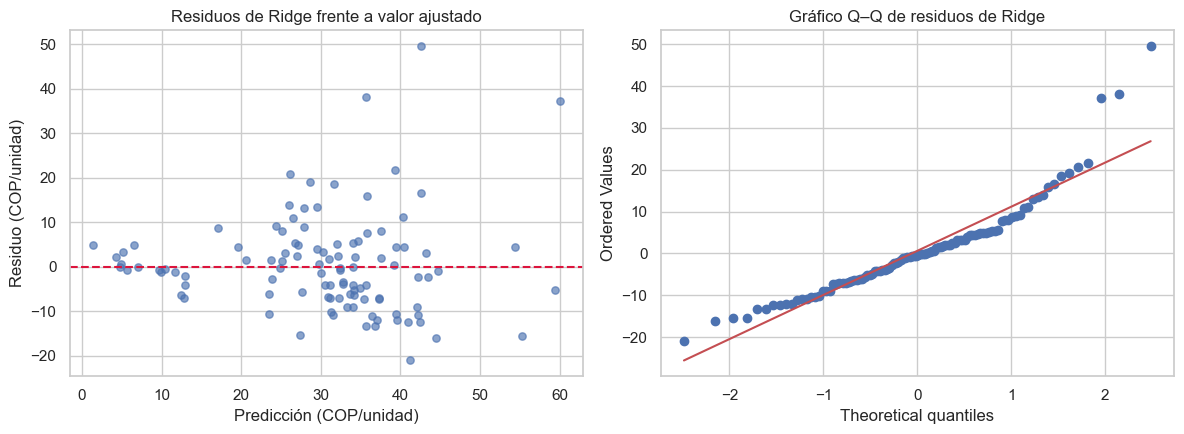

In [35]:
from scipy.stats import normaltest, probplot
from statsmodels.api import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan

residuos_ridge = y_test_final.to_numpy() - pred_ridge_prueba
stat_norm_res, p_norm_res = normaltest(residuos_ridge)
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuos_ridge, add_constant(pred_ridge_prueba))
print(f"Normalidad de residuos Ridge (D’Agostino–Pearson): K²={stat_norm_res:.3f}; p={p_norm_res:.3e}")
print(f"Breusch–Pagan contra valor ajustado: LM={bp_lm:.3f}; p={bp_p:.3e}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_ridge_prueba, residuos_ridge, alpha=.65, s=28)
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set(title="Residuos de Ridge frente a valor ajustado", xlabel="Predicción (COP/unidad)", ylabel="Residuo (COP/unidad)")
probplot(residuos_ridge, dist="norm", plot=axes[1])
axes[1].set_title("Gráfico Q–Q de residuos de Ridge")
plt.tight_layout()

En los residuos de Ridge, D’Agostino–Pearson rechaza normalidad (K² = **44,275**; p < **0,001**) y Breusch–Pagan detecta heterocedasticidad frente al valor ajustado (LM = **8,695**; p = **0,003**). El gráfico residuo–ajuste permite buscar dispersión no constante o sesgo; el gráfico Q–Q muestra desviaciones en las colas. Estas características importan para inferencia y calibración de intervalos, aunque el error en prueba es la medida central del desempeño predictivo.

n_entrenamiento,R2_entrenamiento,R2_validacion_media,R2_validacion_sd
101,0.702,0.344,0.047
180,0.687,0.418,0.055
259,0.671,0.459,0.07
338,0.673,0.477,0.068


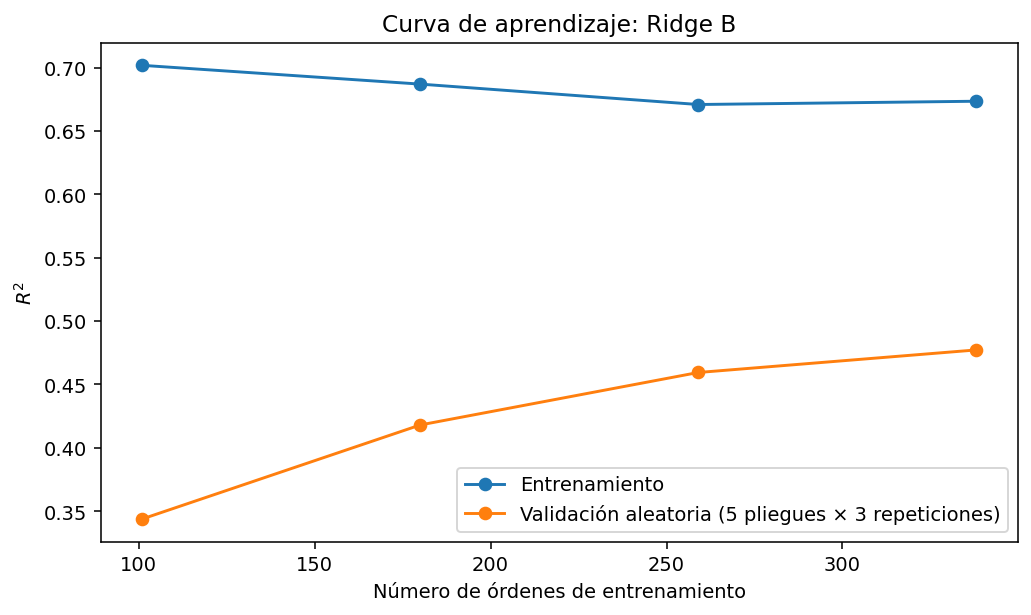

In [37]:
# Curva de aprendizaje de Ridge B con validación cruzada aleatoria por orden.

cv_curva_aleatoria = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)

tamanos, puntuacion_train, puntuacion_cv = learning_curve(

    modelo_ridge_prueba, X_train_final, y_train_final,

    cv=cv_curva_aleatoria,

    train_sizes=np.linspace(.3, 1.0, 4), scoring="r2", n_jobs=1,

    shuffle=True, random_state=SEMILLA,

)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.plot(tamanos, puntuacion_train.mean(axis=1), marker="o", label="Entrenamiento")

ax.plot(tamanos, puntuacion_cv.mean(axis=1), marker="o", label="Validación aleatoria (5 pliegues × 3 repeticiones)")

ax.set(title="Curva de aprendizaje: Ridge B", xlabel="Número de órdenes de entrenamiento", ylabel="$R^2$")

ax.legend(); plt.tight_layout()

display(pd.DataFrame({"n_entrenamiento": tamanos,

                      "R2_entrenamiento": puntuacion_train.mean(axis=1),

                      "R2_validacion_media": puntuacion_cv.mean(axis=1),

                      "R2_validacion_sd": puntuacion_cv.std(axis=1, ddof=1)}).round(3))


Con validación aleatoria por orden, el R² medio de validación aumenta de **0,344** a **0,477** al pasar de 101 a 338 órdenes, mientras que el R² de entrenamiento disminuye de **0,702** a **0,673**. Con 338 órdenes, la brecha entre ambos es de aproximadamente **0,196**, lo que indica sobreajuste: Ridge ajusta mejor las observaciones de entrenamiento que las órdenes apartadas en cada pliegue. Esta diferencia persiste aunque la validación aleatoria permita compartir productos entre entrenamiento y validación; por tanto, también existe una brecha al predecir órdenes de productos potencialmente conocidos. La validación agrupada por producto muestra una dificultad adicional al transferir el modelo a productos no observados. El R² de validación aleatoria es más comparable con el de la prueba aleatoria (**0,539**), aunque la curva promedia particiones repetidas y distintos tamaños de entrenamiento, mientras que la prueba corresponde a una partición única. La desviación estándar entre pliegues se presenta en la tabla para mostrar la variabilidad de las particiones.

### 5.4 Artefacto Ridge reutilizable

El pipeline Ridge B ya está exportado en `outputs/modelo_ridge_costos/modelo_ridge_costo_transformacion.joblib`, junto con sus metadatos y el código auxiliar de predicción. El artefacto existente se ajustó previamente con las 529 órdenes elegibles y utiliza los predictores de la especificación B. La celda de carga solo abre ese archivo; no vuelve a ajustar el modelo ni selecciona de nuevo `alpha`.

Las métricas de la sección 5.3 corresponden al Ridge ajustado únicamente con el 80 % de desarrollo antes de predecir sobre el 20 % reservado. El artefacto reutilizable incluye posteriormente toda la población elegible, incluida la muestra de prueba, y por ello no debe presentarse como si hubiera sido evaluado de forma independiente con esas mismas métricas.

In [38]:
from pathlib import Path
import json
import joblib

ruta_modelo = Path("outputs/modelo_ridge_costos/modelo_ridge_costo_transformacion.joblib")
ruta_metadatos = Path("outputs/modelo_ridge_costos/metadatos_modelo.json")
if not ruta_modelo.exists() or not ruta_metadatos.exists():
    raise FileNotFoundError("No se encontró el artefacto Ridge y sus metadatos en outputs/modelo_ridge_costos.")
modelo_reutilizable = joblib.load(ruta_modelo)
metadatos_modelo = json.loads(ruta_metadatos.read_text(encoding="utf-8"))
print(f"Modelo cargado: {ruta_modelo}")
print(f"Órdenes de ajuste registradas: {metadatos_modelo['n_ordenes']}; productos: {metadatos_modelo['n_productos']}")
print(f"Alpha registrado: {metadatos_modelo['alpha']:.6g}")

Modelo cargado: outputs\modelo_ridge_costos\modelo_ridge_costo_transformacion.joblib
Órdenes de ajuste registradas: 529; productos: 145
Alpha registrado: 3.16228


Para generar estimaciones, se ingresa una lista JSON de órdenes con estos nueve predictores: `codigo_producto`, `volumen_lote`, `equipo_id`, `categoria_producto`, `insumo_1`, `insumo_2`, `modalidad_proceso`, `tipo_equipo` y `num_insumos`. Una lista puede incluir varias órdenes; las categorías no observadas se procesan como niveles desconocidos.

In [ ]:
import json
import joblib
import pandas as pd

ruta_modelo = "outputs/modelo_ridge_costos/modelo_ridge_costo_transformacion.joblib"
modelo_reutilizable = joblib.load(ruta_modelo)
predictores = [
    "codigo_producto", "volumen_lote", "equipo_id", "categoria_producto",
    "insumo_1", "insumo_2", "modalidad_proceso", "tipo_equipo", "num_insumos"
]
print("Ingresa una lista JSON de órdenes; cada objeto debe incluir:", ", ".join(predictores))
print('Ejemplo: [{"codigo_producto":"SKU001","volumen_lote":2500,"equipo_id":"M14","categoria_producto":5,"insumo_1":"B_T","insumo_2":null,"modalidad_proceso":"X","tipo_equipo":"A1","num_insumos":1}]')
texto_ordenes = input("Órdenes nuevas (JSON): ").strip()
if not texto_ordenes:
    raise ValueError("Se requiere ingresar al menos una orden en formato JSON.")
ordenes_nuevas = pd.DataFrame(json.loads(texto_ordenes))
columnas_faltantes = [c for c in predictores if c not in ordenes_nuevas.columns]
if columnas_faltantes:
    raise ValueError(f"Faltan columnas predictoras requeridas: {columnas_faltantes}")
ordenes_nuevas = ordenes_nuevas[predictores].copy()
ordenes_nuevas["volumen_lote"] = pd.to_numeric(ordenes_nuevas["volumen_lote"], errors="coerce")
ordenes_nuevas["num_insumos"] = pd.to_numeric(ordenes_nuevas["num_insumos"], errors="coerce")
if ordenes_nuevas[["volumen_lote", "num_insumos"]].isna().any().any():
    raise ValueError("volumen_lote y num_insumos deben ser numéricos.")
if (ordenes_nuevas["volumen_lote"] <= 0).any() or (ordenes_nuevas["num_insumos"] <= 0).any():
    raise ValueError("Cada orden debe tener volumen_lote > 0 y num_insumos > 0.")
ordenes_nuevas["pred_costo_transformacion_COP_unidad"] = modelo_reutilizable.predict(ordenes_nuevas[predictores])
display(ordenes_nuevas)

## 6. Evidencia científica y conexión con el problema

La revisión bibliográfica no identifica un estudio idéntico que estime el costo unitario real de transformación de órdenes de cápsulas duras a partir de registros históricos de planta. La evidencia disponible resulta útil desde tres frentes complementarios.

### 6.1 Costos y economía de manufactura farmacéutica

Basu et al. (2008) analizan la estructura de costos de manufactura en compañías farmacéuticas. Schaber et al. (2011) y Sampat et al. (2022) muestran, mediante análisis económicos y tecnoeconómicos, que los costos de manufactura dependen de factores como escala, materias primas, equipos, energía, mano de obra y desempeño del proceso.

Estos trabajos respaldan la idea de que el costo no debe tratarse como una constante por producto: existe una estructura de inductores asociada a cómo y cuánto se fabrica.

### 6.2 Modelado del proceso de cápsulas

Khawam y Schultz (2011), Osorio y Muzzio (2013), Stranzinger et al. (2017) y Loidolt et al. (2017) estudian cómo atributos del material y parámetros del proceso afectan el comportamiento del llenado de cápsulas.

Aunque sus variables objetivo son físicas o de calidad y no monetarias, estos estudios apoyan una idea relevante para este proyecto: **la configuración del producto y del equipo contiene información sobre el comportamiento del proceso**. Esto da fundamento a utilizar producto, equipo, formulación y modalidad como predictores del costo de transformación.

### 6.3 Machine learning en manufactura farmacéutica

Mathe et al. (2020) muestran el uso de datos históricos de lotes industriales para modelar variables de proceso en manufactura farmacéutica. Rezaeizadeh et al. (2026) revisan aplicaciones de machine learning en sólidos orales y destacan oportunidades, pero también limitaciones relacionadas con tamaño de muestra, interpretabilidad y capacidad de generalización.

Rueda Ordonez et al. (2026) constituye el antecedente económico más cercano: compara modelos de machine learning para estimar métricas tecnoeconómicas de manufactura farmacéutica por lotes. Sus datos, sin embargo, provienen de simulación y no de costos reales observados por orden.

En conjunto, la literatura justifica evaluar modelos estadísticos y de machine learning, pero no permite asumir de antemano qué algoritmo será superior en este dataset.


### 6.3 Referencias

- Basu, P. K., Joglekar, G., Rai, S., Suresh, P., & Vernon, J. (2008). Analysis of manufacturing costs in pharmaceutical companies. *Journal of Pharmaceutical Innovation, 3*(1), 30–40. https://doi.org/10.1007/s12247-008-9024-4
- Khawam, A. (2011). Modeling powder encapsulation in dosator-based machines: I. Theory. *International Journal of Pharmaceutics, 421*(2), 203–209. https://doi.org/10.1016/j.ijpharm.2011.10.021
- Khawam, A., & Schultz, L. (2011). Modeling powder encapsulation in dosator-based machines: II. Experimental evaluation. *International Journal of Pharmaceutics, 421*(2), 210–219. https://doi.org/10.1016/j.ijpharm.2011.09.027
- Loidolt, P., Madlmeir, S., & Khinast, J. G. (2017). Mechanistic modeling of a capsule filling process. *International Journal of Pharmaceutics, 532*(1), 47–54. https://doi.org/10.1016/j.ijpharm.2017.08.125
- Mathe, R., Casian, T., & Tomuță, I. (2020). Multivariate feed forward process control and optimization of an industrial, granulation based tablet manufacturing line using historical data. *International Journal of Pharmaceutics, 591*, 119988. https://doi.org/10.1016/j.ijpharm.2020.119988
- Nadeau, M.-C., Kar, A., Roth, R., & Kirchain, R. (2010). A dynamic process-based cost modeling approach to understand learning effects in manufacturing. *International Journal of Production Economics, 128*(1), 223–234. https://doi.org/10.1016/j.ijpe.2010.07.016
- Osorio, J. G., & Muzzio, F. J. (2013). Effects of powder flow properties on capsule filling weight uniformity. *Drug Development and Industrial Pharmacy, 39*(9), 1464–1475. https://doi.org/10.3109/03639045.2012.728227
- Rezaeizadeh, M., Razavi, S. M., & Muzzio, F. J. (2026). Current state of machine learning implementation in pharmaceutical process modeling for oral solid dosage forms. *International Journal of Pharmaceutics, 689*, 126479. https://doi.org/10.1016/j.ijpharm.2025.126479
- Rueda Ordonez, D. A., Mesquita, L. C. da S., & Brandão, A. L. T. (2026). Machine learning-driven techno-economic uncertainty analysis in batch pharmaceutical manufacturing. *ACS Omega, 11*(21), 30431–30447. https://doi.org/10.1021/acsomega.5c09455
- Sampat, C., Kotamarthy, L., Bhalode, P., Chen, Y., Dan, A., Parvani, S., Dholakia, Z., Singh, R., Glasser, B. J., Ierapetritou, M., & Ramachandran, R. (2022). Enabling energy-efficient manufacturing of pharmaceutical solid oral dosage forms via integrated techno-economic analysis and advanced process modeling. *Journal of Advanced Manufacturing and Processing, 4*(4), e10136. https://doi.org/10.1002/amp2.10136
- Schaber, S. D., Gerogiorgis, D. I., Ramachandran, R., Evans, J. M. B., Barton, P. I., & Trout, B. L. (2011). Economic analysis of integrated continuous and batch pharmaceutical manufacturing: A case study. *Industrial & Engineering Chemistry Research, 50*(17), 10083–10092. https://doi.org/10.1021/ie2006752
- Stranzinger, S., Faulhammer, E., Calzolari, V., Biserni, S., Dreu, R., Šibanc, R., Paudel, A., & Khinast, J. G. (2017). The effect of material attributes and process parameters on the powder bed uniformity during a low-dose dosator capsule filling process. *International Journal of Pharmaceutics, 516*(1–2), 9–20. https://doi.org/10.1016/j.ijpharm.2016.11.010


## 7. Conclusiones

1. Después de los filtros quedaron **529 órdenes de 145 productos**. La partición aleatoria dejó **423 órdenes** para EDA y desarrollo y reservó **106** para prueba; **47 productos** aparecen en ambos conjuntos. Se asume estacionariedad y se excluye `periodo`.
2. En validación aleatoria, que aproxima predicciones de órdenes nuevas de un catálogo conocido, Ridge B obtuvo RMSE **10,75 ± 0,98 COP/unidad**, MAE **7,50 ± 0,53** y R² **0,462 ± 0,09**. Ridge A obtuvo RMSE **11,08 ± 0,99**, MAE **7,66 ± 0,52** y R² **0,431 ± 0,07**. La diferencia de R² (**0,032**) no fue significativa tras la corrección de Nadeau–Bengio y Holm (p = **0,166**).
3. En validación agrupada por producto, Ridge B alcanzó R² medio **0,261** (DE = 0,22), frente a **0,185** para A; tampoco se confirmó una mejora significativa al añadir `tipo_equipo` y `num_insumos` (p de Holm = **0,191**). La variabilidad entre pliegues refleja la dificultad de transferir el modelo a productos no vistos.
4. En la evaluación del Ridge B ajustado con el conjunto de desarrollo, la prueba aleatoria obtuvo RMSE **11,00**, MAE **7,69 COP/unidad**, MAPE **26,94 %** y R² **0,539**, frente a RMSE **16,19** y R² aproximadamente **0** de la referencia de la media. El intervalo bootstrap de R² de Ridge fue **[0,252; 0,701]**. La prueba aleatoria mezcla órdenes con códigos conocidos y códigos ausentes de entrenamiento; la validación agrupada aporta la estimación específica para productos no vistos.
5. El costo varía entre categorías de producto y máquina, aunque los grupos pequeños y desbalanceados limitan las comparaciones. Además, 65 de 132 productos (49,2 %) aparecen en una sola orden de desarrollo, lo que deja poco soporte para estimar patrones específicos de muchos códigos. La curva de aprendizaje presenta una brecha de R² de **0,196** entre entrenamiento y validación aleatoria con 338 órdenes, indicio de sobreajuste incluso para órdenes de productos potencialmente conocidos. La validación agrupada evidencia una dificultad mayor para productos no observados. Los residuos de prueba también muestran desviaciones de normalidad y heterocedasticidad. Ridge constituye una línea base útil, pero su generalización sigue siendo limitada y requiere cautela antes de cualquier uso operativo.
